# 08 — Structured Cross-Validation Scenarios with `trustcv`

### Temporal · Spatial · Hierarchical Data — Supplementary Notebook S3

> **Package:** `trustcv` · leakage-aware cross-validation for medical machine learning  
> **Purpose:** educational, executable examples showing how validation strategy changes when data are time-ordered, spatially autocorrelated, or hierarchically grouped.

---

## Why this notebook exists

The main grouped benchmark demonstrates why ordinary record-wise K-Fold can be unsafe when repeated observations from the same patient are split across train and test sets. This notebook extends that idea to three additional structured-data situations that are common in medical ML:

1. **ICU temporal monitoring** — repeated hourly observations with time ordering and patient identity.
2. **Spatial epidemiology** — geographically clustered risk where nearby locations are correlated.
3. **Multisite clinical trials** — visits nested within patients and patients nested within hospitals/sites.

The goal is not to create a clinical benchmark. The datasets are synthetic by design, so the reported AUC values should be interpreted as **software-execution and leakage-audit demonstrations**. The key question is whether each splitter preserves the structure that would be required in a realistic deployment setting.

---

## Learning objectives

After running this notebook, the reader should be able to:

- distinguish **temporal-only**, **patient/group-only**, and **hybrid temporal + grouped** validation;
- see why random K-Fold can create structural leakage even when the model code is correct;
- understand why spatial blocking may reduce but not always eliminate geographic proximity leakage;
- compare patient-level grouping with site-level or hospital-level grouping;
- use `DataLeakageChecker` to audit each fold.

---

## How to read the result tables

- **Pooled OOF AUC** is calculated from pooled out-of-fold predictions and is the main metric shown here.
- **Fold AUC mean ± SD** is a split-stability diagnostic, not the primary estimate.
- **FLAG** means `DataLeakageChecker` detected a structural issue in at least one fold.
- **PASS** means no structural issue was detected under the checks used in that scenario.


## Cell 1 — Install and import dependencies

This setup cell is designed to work in three environments:

1. **Inside the TrustCV repository** — imports the local source tree.
2. **In Colab after cloning the repository** — imports from `/content/trustcv` or `/content/trustcv-main` when present.
3. **In a fresh Colab session** — installs TrustCV from GitHub as a fallback.

The notebook uses a small random forest baseline throughout. The aim is to compare validation designs, not to optimize model performance.


In [1]:
# ── Step 1: Install/import trustcv ────────────────────────────────────────────
import os
import sys
import subprocess
from pathlib import Path

# Candidate local repository locations. The first valid path is used.
LOCAL_CANDIDATES = [
    Path.cwd(),
    Path.cwd().parent,
    Path("/content/trustcv"),
    Path("/content/trustcv-main"),
    Path("/mnt/data/tcv/trustcv-main"),      # used only in this notebook-building environment
    Path("/mnt/data/trustcv-main"),
]

local_repo = None
for candidate in LOCAL_CANDIDATES:
    if (candidate / "trustcv" / "__init__.py").exists():
        local_repo = candidate
        break

if local_repo is not None:
    sys.path.insert(0, str(local_repo))
    print(f"Using local trustcv source: {local_repo}")
else:
    print("Installing trustcv from GitHub...")
    subprocess.check_call([
        sys.executable, "-m", "pip", "install", "-q",
        "git+https://github.com/ki-smile/trustcv.git"
    ])

# Extra plotting dependency used by this notebook. Install only if missing.
try:
    import plotly  # noqa: F401
except Exception:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "plotly"])

# ── Step 2: Verify installation ───────────────────────────────────────────────
try:
    import trustcv
    print("trustcv imported; version:", getattr(trustcv, "__version__", "unknown"))
except Exception as exc:
    raise RuntimeError("trustcv could not be imported. Check the installation path or GitHub access.") from exc


Using local trustcv source: /mnt/data/tcv/trustcv-main


trustcv imported; version: 1.0.7


In [2]:
# ── Standard scientific libraries ─────────────────────────────────────────────
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
from matplotlib.gridspec import GridSpec
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from IPython.display import display, HTML

# ── trustcv — top-level exports ───────────────────────────────────────────────
from trustcv import (
    # Framework-agnostic CV engine
    UniversalCVRunner,
    CVResults,

    # Callbacks
    LeakageDetectionCallback,
    ClassDistributionLogger,

    # Leakage detection
    DataLeakageChecker,

    # Grouped splitters
    GroupKFoldMedical,
    HierarchicalGroupKFold,
    LeaveOneGroupOut,
)

# ── trustcv — splitters ───────────────────────────────────────────────────────
from trustcv.splitters import (
    KFold,                          # Standard (used as incorrect baseline)
    TimeSeriesSplit,                # Temporal forward-chaining
    PurgedGroupTimeSeriesSplit,     # Temporal + groups + purge gap
    SpatialBlockCV,                 # Geographic block splitting
    BufferedSpatialCV,              # Spatial blocks + buffer exclusion zone
)

# ── trustcv — metrics ─────────────────────────────────────────────────────────
from trustcv.metrics import ClinicalMetrics, oob_clinical_metrics

# ── sklearn helpers ───────────────────────────────────────────────────────────
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.base import clone
from sklearn.metrics import roc_auc_score, confusion_matrix

# ── Global model (used across all scenarios) ──────────────────────────────────
# We use a RandomForestClassifier inside a pipeline.
# StandardScaler normalizes features (good practice).
# RandomForest is a solid, widely-used baseline for tabular medical data.
BASE_MODEL = make_pipeline(
    StandardScaler(),
    RandomForestClassifier(n_estimators=30, max_depth=5,
                           min_samples_leaf=2, random_state=42, n_jobs=1)
)

# ── Clinical metrics object (used across all scenarios) ───────────────────────
CLINICAL = ClinicalMetrics(confidence_level=0.95)

# ── Structural leakage types (patient, temporal, spatial) ─────────────────────
# trustcv also detects 'near_duplicate' and 'preprocessing' leakage.
# For this notebook we focus on structural CV violations only.
STRUCTURAL_TYPES = {"patient", "temporal", "spatial", "spatial_proximity"}

def is_structural_flag(report):
    """Returns True only if a structural leakage type was detected."""
    return bool(set(report.leakage_types) & STRUCTURAL_TYPES)

print("All imports OK ✓")
print()
print("Model used throughout:")
print(f"  {BASE_MODEL}")

All imports OK ✓

Model used throughout:
  Pipeline(steps=[('standardscaler', StandardScaler()),
                ('randomforestclassifier',
                 RandomForestClassifier(max_depth=5, min_samples_leaf=2,
                                        n_estimators=30, n_jobs=1,
                                        random_state=42))])


## Cell 2 — Helper Functions

These helper functions are used throughout the notebook to:
1. **Visualize fold splits** — see which data goes to train vs test
2. **Run CV and collect results** — standard pattern we reuse
3. **Print leakage reports** — understand what `DataLeakageChecker` found

In [3]:
# ── Helper 1: Visualize fold assignments ─────────────────────────────────────
def plot_fold_assignment(splits, n_samples, title, color_train="#4878CF",
                         color_test="#E87849", max_folds=6):
    """Shows which samples go to train/test in each fold."""
    splits = list(splits)[:max_folds]
    n_folds = len(splits)
    fig, ax = plt.subplots(figsize=(12, 0.55 * n_folds + 1.2))

    for fold_i, (train_idx, test_idx) in enumerate(splits):
        assignment = np.full(n_samples, np.nan)
        train_idx = np.asarray(train_idx)
        test_idx = np.asarray(test_idx)
        assignment[train_idx[train_idx < n_samples]] = 0
        assignment[test_idx[test_idx < n_samples]] = 1

        cmap = mcolors.ListedColormap([color_train, color_test])
        ax.scatter(range(n_samples), [fold_i] * n_samples,
                   c=assignment, cmap=cmap, vmin=0, vmax=1,
                   s=6, marker="s", linewidths=0)
        ax.set_yticks(range(n_folds))
        ax.set_yticklabels([f"Fold {i+1}" for i in range(n_folds)], fontsize=9)

    ax.set_xlabel("Sample index", fontsize=9)
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.invert_yaxis()
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    legend = [
        mpatches.Patch(color=color_train, label="Train set"),
        mpatches.Patch(color=color_test,  label="Test set"),
    ]
    ax.legend(handles=legend, loc="upper right", fontsize=9)
    plt.tight_layout()
    plt.show()


def _bootstrap_auc_ci(y_true, y_score, n_boot=200, seed=42):
    y_true = np.asarray(y_true)
    y_score = np.asarray(y_score)
    rng = np.random.default_rng(seed)
    vals = []
    n = len(y_true)
    for _ in range(n_boot):
        idx = rng.integers(0, n, n)
        if len(np.unique(y_true[idx])) < 2:
            continue
        vals.append(roc_auc_score(y_true[idx], y_score[idx]))
    if not vals:
        return np.nan, np.nan
    return float(np.percentile(vals, 2.5)), float(np.percentile(vals, 97.5))


def _binary_metrics(y_true, y_score, threshold=0.5):
    y_pred = (np.asarray(y_score) >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    sensitivity = tp / (tp + fn) if (tp + fn) else np.nan
    specificity = tn / (tn + fp) if (tn + fp) else np.nan
    accuracy = (tp + tn) / (tp + tn + fp + fn)
    return float(sensitivity), float(specificity), float(accuracy)


def _patient_level_auc(y_true, y_score, patient_ids):
    df = pd.DataFrame({"patient": patient_ids, "y": y_true, "score": y_score})
    p = df.groupby("patient", as_index=False).agg(y=("y", "max"), score=("score", "mean"))
    if p["y"].nunique() < 2:
        return np.nan
    return float(roc_auc_score(p["y"], p["score"]))


# ── Helper 2: Run CV and collect pooled OOF results ──────────────────────────
def run_scenario(label, splitter, X, y, *,
                 groups=None, timestamps=None, coords=None,
                 leakage_groups=None, leakage_ts=None, leakage_coords=None,
                 spatial_threshold=None,
                 verbose=True):
    """
    Runs a trustcv splitter, fits a sklearn model fold-by-fold, and audits every fold.

    The main AUC reported here is pooled out-of-fold AUC. Fold-wise AUC mean/SD
    is retained as a stability diagnostic only.
    """
    checker = DataLeakageChecker(verbose=False)

    split_kwargs = {}
    if groups is not None:
        split_kwargs["groups"] = groups
    if timestamps is not None:
        split_kwargs["timestamps"] = timestamps
    if coords is not None:
        split_kwargs["coordinates"] = coords

    try:
        splits = list(splitter.split(X, y, **split_kwargs))
    except TypeError:
        # Some splitters do not accept all metadata arguments.
        reduced = {k: v for k, v in split_kwargs.items() if k in {"groups"}}
        splits = list(splitter.split(X, y, **reduced))

    oof_score = np.full(len(y), np.nan)
    fold_aucs, all_leakage_types = [], set()
    patient_overlap_counts, temporal_flags, spatial_near_fracs = [], [], []
    any_structural_flag = False

    for tr, te in splits:
        tr, te = np.asarray(tr), np.asarray(te)
        if len(tr) == 0 or len(te) == 0:
            continue

        model = clone(BASE_MODEL)
        model.fit(X[tr], y[tr])
        proba = model.predict_proba(X[te])[:, 1]
        oof_score[te] = proba

        if len(np.unique(y[te])) >= 2:
            fold_aucs.append(float(roc_auc_score(y[te], proba)))

        # Use tiny dummy feature arrays for the leakage checker so this notebook runs quickly.
        # The structural checks below depend on patient IDs, timestamps, and coordinates,
        # not on the full feature matrix. This avoids expensive near-duplicate comparisons
        # on large synthetic folds while still exercising DataLeakageChecker.check_cv_splits().
        report = checker.check_cv_splits(
            X_train=np.zeros((1, 1)), X_test=np.ones((1, 1)),
            y_train=y[tr], y_test=y[te],
            patient_ids_train=leakage_groups[tr] if leakage_groups is not None else None,
            patient_ids_test=leakage_groups[te] if leakage_groups is not None else None,
            timestamps_train=leakage_ts[tr] if leakage_ts is not None else None,
            timestamps_test=leakage_ts[te] if leakage_ts is not None else None,
            coordinates_train=leakage_coords[tr] if leakage_coords is not None else None,
            coordinates_test=leakage_coords[te] if leakage_coords is not None else None,
            spatial_threshold=spatial_threshold,
        )
        structural = set(report.leakage_types) & STRUCTURAL_TYPES
        all_leakage_types.update(structural)
        if structural:
            any_structural_flag = True
        patient_overlap_counts.append(report.details.get("patient_leakage", {}).get("overlap_count", 0))
        temporal_flags.append("temporal" in report.leakage_types)
        if "spatial_proximity" in report.details:
            spatial_near_fracs.append(report.details["spatial_proximity"].get("near_fraction", 0.0))

    mask = ~np.isnan(oof_score)
    if mask.sum() == 0 or len(np.unique(y[mask])) < 2:
        return None

    pooled_auc = float(roc_auc_score(y[mask], oof_score[mask]))
    ci_lo, ci_hi = _bootstrap_auc_ci(y[mask], oof_score[mask])
    sens, spec, acc = _binary_metrics(y[mask], oof_score[mask])
    patient_auc = _patient_level_auc(y[mask], oof_score[mask], leakage_groups[mask]) if leakage_groups is not None else np.nan

    auc_arr = np.array(fold_aucs)
    mean_fold_auc = float(np.mean(auc_arr)) if len(auc_arr) else np.nan
    sd_fold_auc = float(np.std(auc_arr, ddof=1)) if len(auc_arr) > 1 else np.nan

    result = {
        "auc": pooled_auc,
        "sd": sd_fold_auc,
        "ci_lo": ci_lo,
        "ci_hi": ci_hi,
        "sensitivity": sens,
        "specificity": spec,
        "accuracy": acc,
        "patient_auc": patient_auc,
        "flagged": any_structural_flag,
        "leakage_types": sorted(all_leakage_types),
        "fold_aucs": fold_aucs,
        "fold_auc_mean": mean_fold_auc,
        "patient_overlap_folds": int(sum(np.asarray(patient_overlap_counts) > 0)) if patient_overlap_counts else 0,
        "max_patient_overlap": int(max(patient_overlap_counts)) if patient_overlap_counts else 0,
        "temporal_violation_folds": int(sum(temporal_flags)) if temporal_flags else 0,
        "spatial_near_fraction": float(np.mean(spatial_near_fracs)) if spatial_near_fracs else np.nan,
    }

    if verbose:
        flag_str = "🚨 FLAG" if any_structural_flag else "✅ PASS"
        print(f"  {flag_str}  {label}")
        print(f"         pooled OOF AUC = {pooled_auc:.3f}  95% CI [{ci_lo:.3f}, {ci_hi:.3f}]")
        print(f"         fold AUC mean = {mean_fold_auc:.3f} ± {sd_fold_auc:.3f}")
        if not np.isnan(patient_auc):
            print(f"         patient-level AUC = {patient_auc:.3f}")
        print(f"         Se={sens:.3f}, Sp={spec:.3f}")
        if all_leakage_types:
            print(f"         Structural leakage/audit flags: {sorted(all_leakage_types)}")
        print(f"         patient-overlap folds={result['patient_overlap_folds']}; temporal-violation folds={result['temporal_violation_folds']}")
        if not np.isnan(result["spatial_near_fraction"]):
            print(f"         mean spatial near fraction={result['spatial_near_fraction']:.3f}")
        print()

    return result


# ── Helper 3: Bar chart comparing methods ─────────────────────────────────────
def plot_method_comparison(results_dict, title, ref_key=None):
    names  = [k for k, v in results_dict.items() if v is not None]
    aucs   = [results_dict[n]["auc"]     for n in names]
    ci_los = [results_dict[n]["ci_lo"]   for n in names]
    ci_his = [results_dict[n]["ci_hi"]   for n in names]
    flags  = [results_dict[n]["flagged"] for n in names]

    bar_colors = []
    for n, f in zip(names, flags):
        if f:                             bar_colors.append("#D62728")
        elif ref_key and n == ref_key:    bar_colors.append("#1F77B4")
        else:                             bar_colors.append("#7F7F7F")

    y_pos = np.arange(len(names))
    fig, ax = plt.subplots(figsize=(9, 0.6 * len(names) + 1.5))
    ax.barh(y_pos, aucs, color=bar_colors, height=0.5,
            edgecolor="white", zorder=2)

    for i, (lo, hi) in enumerate(zip(ci_los, ci_his)):
        ax.plot([lo, hi], [i, i], color="#333333", lw=1.8,
                solid_capstyle="round", zorder=3)
        ax.plot([lo, hi], [i, i], "|", color="#333333",
                markersize=5, zorder=3)

    if ref_key and ref_key in results_dict:
        ref_auc = results_dict[ref_key]["auc"]
        ax.axvline(ref_auc, color="#1F77B4", ls="--",
                   lw=1.2, alpha=0.7, zorder=1, label="Reference")
        for i, (n, auc, flag) in enumerate(zip(names, aucs, flags)):
            delta = auc - ref_auc
            sign  = "+" if delta >= 0 else ""
            ax.text(auc + 0.006, i, f"{auc:.3f} ({sign}{delta:.3f})",
                    va="center", fontsize=8, color="#333333")
    else:
        for i, auc in enumerate(aucs):
            ax.text(auc + 0.006, i, f"{auc:.3f}", va="center", fontsize=8)

    ax.set_yticks(y_pos)
    ax.set_yticklabels([n.replace("\n", " ") for n in names], fontsize=9)
    ax.set_xlabel("Pooled out-of-fold AUC", fontsize=9)
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.set_xlim(max(0.45, min(aucs) - 0.05), min(1.0, max(aucs) + 0.08))
    ax.invert_yaxis()
    ax.grid(axis="x", alpha=0.25)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    plt.tight_layout()
    plt.show()

print("Helper functions defined ✓")


Helper functions defined ✓


---
# PART 1 — ICU Monitoring: Temporal Data

## 🩺 Clinical Context

Imagine you are building a model to predict **ICU patient deterioration**.  
Each patient has hourly vital sign measurements for 1–3 days.

The critical question: *when a new patient enters the ICU tomorrow, how well will your model work?*

### The temporal leakage problem

Standard K-Fold randomly shuffles observations across folds.  
This means **hour 47 from day 3 might train your model on hours 1–2 from day 1 of the same patient**.  
The model learns from the "future" — which is impossible in deployment.

> **Key rule:** In temporal data, training always uses the *past*, testing uses the *future*.

## Cell 3 — Generate ICU Dataset

In [4]:
# ── Generate ICU monitoring dataset ──────────────────────────────────────────
# 120 ICU patients, each monitored for 24-72 hours.
# Features: vital signs (simulated with AR(1) temporal dependence)
# Outcome: binary (1 = deterioration event, 0 = stable)

def generate_icu_data(seed=42):
    """
    Synthetic ICU dataset.
    Each patient has hourly observations with AR(1) temporal autocorrelation.
    Patient-level signal creates leakage when K-Fold is used.
    """
    rng = np.random.default_rng(seed)
    records, patient_ids, timestamps = [], [], []
    patient_outcomes = {}
    t = 0
    for pid in range(120):
        n_hours  = rng.integers(24, 73)
        outcome  = int(rng.random() < 0.38)   # 38% deterioration rate
        patient_outcomes[pid] = outcome

        # Patient-specific physiological fingerprint
        patient_fp = rng.normal(outcome * 0.9, 0.7, 3)
        ar_coef    = rng.uniform(0.5, 0.75)   # autocorrelation coefficient
        state      = rng.normal(0, 1)

        for h in range(n_hours):
            # AR(1) process: current state depends on previous state
            state = ar_coef * state + rng.normal(0, 1.0)
            records.append([
                state + outcome * 0.25,          # vital sign 1 (correlated with outcome)
                patient_fp[0] + rng.normal(0, 1.1),  # patient fingerprint feature 1
                patient_fp[1] + rng.normal(0, 1.1),  # patient fingerprint feature 2
                patient_fp[2] + rng.normal(0, 1.1),  # patient fingerprint feature 3
                np.sin(2 * np.pi * h / 24),      # circadian rhythm (sine)
                np.cos(2 * np.pi * h / 24),      # circadian rhythm (cosine)
                rng.normal(0, 1),                # noise feature
                float(h) / n_hours,              # time fraction (0 = admission, 1 = end)
            ])
            patient_ids.append(pid)
            timestamps.append(t)
            t += 1

    X   = np.array(records)
    y   = np.array([patient_outcomes[p] for p in patient_ids])
    pids = np.array(patient_ids)
    ts  = np.array(timestamps)

    # Sort by global timestamp (important for temporal CV)
    order = np.argsort(ts)
    return X[order], y[order], pids[order], ts[order]


X_icu, y_icu, pids_icu, ts_icu = generate_icu_data(seed=42)
days_icu = ts_icu // 24   # day-based groups (used by PurgedGroupTimeSeriesSplit)

# ── Summary ───────────────────────────────────────────────────────────────────
print("=" * 50)
print("  ICU MONITORING DATASET")
print("=" * 50)
print(f"  Total observations : {len(X_icu):,}")
print(f"  Number of patients : {len(np.unique(pids_icu))}")
print(f"  Number of features : {X_icu.shape[1]}")
print(f"  Obs per patient    : {len(X_icu)/len(np.unique(pids_icu)):.1f} (average)")
print(f"  Outcome balance    : {y_icu.mean()*100:.1f}% deterioration")
print(f"  Time span          : {ts_icu.max()+1:,} global time steps")
print(f"  Temporal groups    : {len(np.unique(days_icu))} days")
print()

# ── Show first few rows ───────────────────────────────────────────────────────
feature_names = ["vital_AR1", "fingerprint_1", "fingerprint_2", "fingerprint_3",
                 "circadian_sin", "circadian_cos", "noise", "time_fraction"]
df_view = pd.DataFrame(X_icu[:5], columns=feature_names).round(3)
df_view.insert(0, "patient_id",  pids_icu[:5])
df_view.insert(1, "timestamp",   ts_icu[:5])
df_view.insert(2, "outcome",     y_icu[:5])
print("Sample rows:")
display(df_view)

  ICU MONITORING DATASET
  Total observations : 5,786
  Number of patients : 120
  Number of features : 8
  Obs per patient    : 48.2 (average)
  Outcome balance    : 34.6% deterioration
  Time span          : 5,786 global time steps
  Temporal groups    : 242 days

Sample rows:


,patient_id,timestamp,outcome,vital_AR1,fingerprint_1,fingerprint_2,fingerprint_3,circadian_sin,circadian_cos,noise,time_fraction
0,0,0,0,-0.221,0.507,-0.280,-0.398,0.000,1.000,0.778,0.000
1,0,1,0,-0.098,1.765,1.173,-2.311,0.259,0.966,0.369,0.036
2,0,2,0,-1.032,1.492,0.603,-1.569,0.500,0.866,-0.681,0.071
3,0,3,0,0.455,0.355,0.187,-1.753,0.707,0.707,0.532,0.107
4,0,4,0,0.704,0.979,1.132,0.990,0.866,0.500,-0.406,0.143


## Cell 4 — Visualize the Temporal Structure

Before choosing a CV method, always **look at your data structure**.  
The plot below shows that:
- Each patient has multiple observations (rows) spread over time
- Observations from the same patient cluster together
- The outcome is a patient-level label (all observations share it)

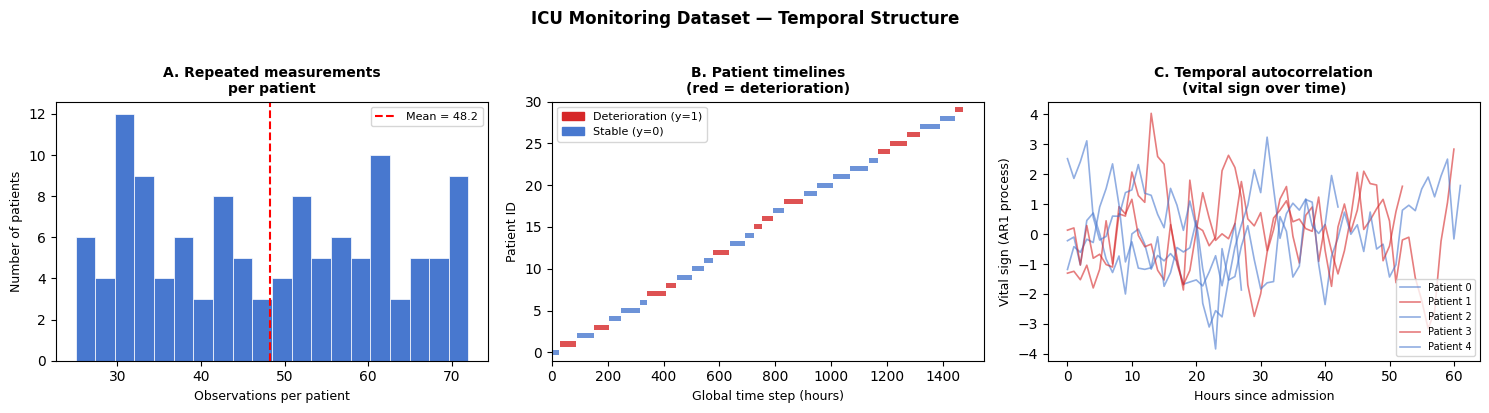


Key observations:
  1. Each patient has 24-72 observations (repeated measures problem)
  2. Patients are ordered in time — earlier patients appear before later ones
  3. The vital sign has clear autocorrelation (tomorrow's value ≈ today's value)
  → Both patient structure AND temporal order must be respected in CV


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Plot A: Observations per patient (histogram)
obs_per_patient = np.bincount(pids_icu)
axes[0].hist(obs_per_patient, bins=20, color="#4878CF", edgecolor="white", linewidth=0.5)
axes[0].set_xlabel("Observations per patient", fontsize=9)
axes[0].set_ylabel("Number of patients", fontsize=9)
axes[0].set_title("A. Repeated measurements\nper patient", fontweight="bold", fontsize=10)
axes[0].axvline(obs_per_patient.mean(), color="red", ls="--",
                label=f"Mean = {obs_per_patient.mean():.1f}")
axes[0].legend(fontsize=8)

# Plot B: Timeline of first 30 patients
n_show = 30
for pid in range(n_show):
    mask = pids_icu == pid
    t_start = ts_icu[mask].min()
    t_end   = ts_icu[mask].max()
    color   = "#D62728" if y_icu[mask][0] == 1 else "#4878CF"
    axes[1].barh(pid, t_end - t_start, left=t_start, height=0.6,
                 color=color, alpha=0.8)
axes[1].set_xlabel("Global time step (hours)", fontsize=9)
axes[1].set_ylabel("Patient ID", fontsize=9)
axes[1].set_title("B. Patient timelines\n(red = deterioration)", fontweight="bold", fontsize=10)
legend_pats = [
    mpatches.Patch(color="#D62728", label="Deterioration (y=1)"),
    mpatches.Patch(color="#4878CF", label="Stable (y=0)"),
]
axes[1].legend(handles=legend_pats, fontsize=8)
axes[1].set_ylim(-1, n_show)

# Plot C: AR(1) signal for 5 patients
for pid in range(5):
    mask   = pids_icu == pid
    t_vals = ts_icu[mask] - ts_icu[mask].min()
    color  = "#D62728" if y_icu[mask][0] == 1 else "#4878CF"
    axes[2].plot(t_vals, X_icu[mask, 0], color=color, alpha=0.6,
                 linewidth=1.2, label=f"Patient {pid}")
axes[2].set_xlabel("Hours since admission", fontsize=9)
axes[2].set_ylabel("Vital sign (AR1 process)", fontsize=9)
axes[2].set_title("C. Temporal autocorrelation\n(vital sign over time)", fontweight="bold", fontsize=10)
axes[2].legend(fontsize=7)

plt.suptitle("ICU Monitoring Dataset — Temporal Structure",
             fontsize=12, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

print()
print("Key observations:")
print("  1. Each patient has 24-72 observations (repeated measures problem)")
print("  2. Patients are ordered in time — earlier patients appear before later ones")
print("  3. The vital sign has clear autocorrelation (tomorrow's value ≈ today's value)")
print("  → Both patient structure AND temporal order must be respected in CV")

## Cell 5 — Why K-Fold Fails on Time-Series Data

### The problem visualized

K-Fold randomly assigns observations to folds, **ignoring time order**.  
The fold assignment plot below shows that test observations (orange) are randomly scattered — they can appear *before* training observations.

This means the model trains on **hour 60** and tests on **hour 10** of the same patient.  
It has seen the future. This is **temporal leakage**.

> 📌 **What `DataLeakageChecker` will detect:**  
> - `'patient'` leakage — same patient in train and test  
> - `'temporal'` leakage — test data precedes training data in time

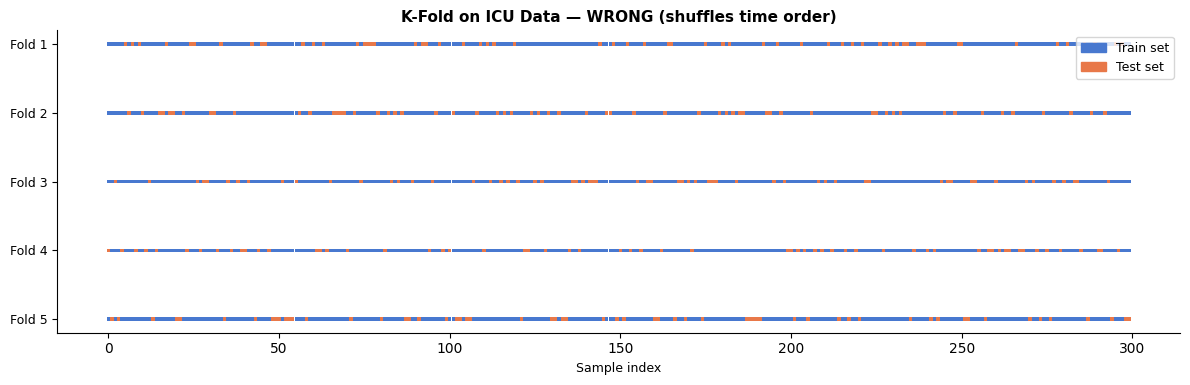

❌ Problem: Test observations (orange) can appear at any time position.
   This means the model may learn from future data — temporal leakage!



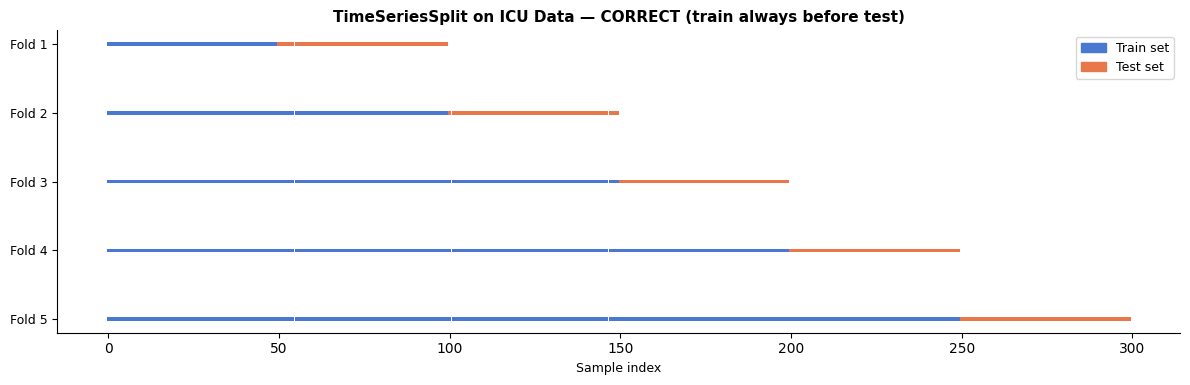

✅ TimeSeriesSplit: Test (orange) always comes AFTER training (blue).
   This mirrors real deployment: train on past, predict future.


In [6]:
# ── Show K-Fold split assignments ─────────────────────────────────────────────
kf_splitter = KFold(n_splits=5, shuffle=True, random_state=42)

# Use a small subset (first 300 obs) for clear visualization
n_vis = 300
plot_fold_assignment(
    kf_splitter.split(X_icu[:n_vis], y_icu[:n_vis]),
    n_vis,
    "K-Fold on ICU Data — WRONG (shuffles time order)",
    color_train="#4878CF", color_test="#E87849"
)

print("❌ Problem: Test observations (orange) can appear at any time position.")
print("   This means the model may learn from future data — temporal leakage!")
print()

# ── Now show TimeSeriesSplit for contrast ─────────────────────────────────────
ts_splitter_vis = TimeSeriesSplit(n_splits=5, gap=0)
plot_fold_assignment(
    ts_splitter_vis.split(X_icu[:n_vis], y_icu[:n_vis], timestamps=ts_icu[:n_vis]),
    n_vis,
    "TimeSeriesSplit on ICU Data — CORRECT (train always before test)",
    color_train="#4878CF", color_test="#E87849"
)

print("✅ TimeSeriesSplit: Test (orange) always comes AFTER training (blue).")
print("   This mirrors real deployment: train on past, predict future.")

## Cell 6 — Run temporal and hybrid validation methods with `trustcv`

This cell compares four strategies on the same ICU-like dataset.

| Method | What it respects | What it ignores | Interpretation |
|---|---|---|---|
| `KFold` | neither time nor patient identity | time and patients | intentionally wrong baseline |
| `TimeSeriesSplit` | chronological order | patient exclusivity | temporal-only correction |
| `GroupKFoldMedical` | patient exclusivity | chronological order | patient-only correction |
| `PurgedGroupTimeSeriesSplit` | chronological order, purge gap, and patient exclusivity | — | hybrid temporal + grouped validation |

The most important conceptual point is that a longitudinal clinical dataset can violate **two assumptions at once**. A splitter may fix one problem while leaving another one unresolved. The hybrid splitter is therefore the appropriate choice when both time ordering and repeated patient measurements matter.


In [7]:
print("=" * 60)
print("  RUNNING: ICU Monitoring — Temporal CV Methods")
print("  DataLeakageChecker audits patient overlap and temporal ordering")
print("=" * 60)
print()

icu_results = {}

# ── Method 1: K-Fold (incorrect baseline) ─────────────────────────────────────
print("Method 1: KFold (incorrect baseline — ignores patient grouping and time)")
icu_results["KFold\n(no structure)"] = run_scenario(
    "KFold",
    KFold(n_splits=5, shuffle=True, random_state=42),
    X_icu, y_icu,
    leakage_groups=pids_icu,   # audit patient overlap
    leakage_ts=ts_icu,         # audit temporal order
)

# ── Method 2: TimeSeriesSplit ──────────────────────────────────────────────────
# gap=24 leaves a 24-sample buffer between train end and test start.
# This preserves deployment chronology: train on past, predict future.
print("Method 2: TimeSeriesSplit (temporal-only forward-chaining, gap=24)")
icu_results["TimeSeriesSplit"] = run_scenario(
    "TimeSeriesSplit",
    TimeSeriesSplit(n_splits=5, gap=24),
    X_icu, y_icu,
    timestamps=ts_icu,         # split by time
    leakage_ts=ts_icu,         # audit temporal order
)

# ── Method 3: GroupKFoldMedical ────────────────────────────────────────────────
# Keeps all observations from the same patient in the same fold.
# This prevents patient-level leakage but is not a temporal forward-chaining design.
print("Method 3: GroupKFoldMedical (patient/group-only validation)")
icu_results["GroupKFoldMedical"] = run_scenario(
    "GroupKFoldMedical",
    GroupKFoldMedical(n_splits=5, random_state=42),
    X_icu, y_icu,
    groups=pids_icu,           # split by patient
    leakage_groups=pids_icu,   # audit patient overlap
)

# ── Method 4: PurgedGroupTimeSeriesSplit ──────────────────────────────────────
# The most rigorous method in this example.
# It combines: temporal ordering + purge gap + patient exclusivity.
# group_exclusive=True removes training samples from any patient appearing in the test fold.
print("Method 4: PurgedGroupTimeSeriesSplit (hybrid temporal + grouped + purge gap)")
icu_results["PurgedGroupTS"] = run_scenario(
    "PurgedGroupTimeSeriesSplit",
    PurgedGroupTimeSeriesSplit(
        n_splits=5,
        purge_gap=24,
        embargo_size=0.0,
        group_exclusive=True,
    ),
    X_icu, y_icu,
    groups=pids_icu,           # patient identifiers used for group exclusivity
    timestamps=ts_icu,         # respect temporal order
    leakage_groups=pids_icu,   # audit patient overlap
    leakage_ts=ts_icu,         # audit temporal order
)

print("\nAll methods complete ✓")


  RUNNING: ICU Monitoring — Temporal CV Methods
  DataLeakageChecker audits patient overlap and temporal ordering

Method 1: KFold (incorrect baseline — ignores patient grouping and time)


  🚨 FLAG  KFold
         pooled OOF AUC = 0.746  95% CI [0.734, 0.759]
         fold AUC mean = 0.748 ± 0.012
         patient-level AUC = 0.912
         Se=0.324, Sp=0.920
         Structural leakage/audit flags: ['patient', 'temporal']
         patient-overlap folds=5; temporal-violation folds=5

Method 2: TimeSeriesSplit (temporal-only forward-chaining, gap=24)


  ✅ PASS  TimeSeriesSplit
         pooled OOF AUC = 0.711  95% CI [0.695, 0.724]
         fold AUC mean = 0.729 ± 0.113
         Se=0.358, Sp=0.861
         patient-overlap folds=0; temporal-violation folds=0

Method 3: GroupKFoldMedical (patient/group-only validation)


  ✅ PASS  GroupKFoldMedical
         pooled OOF AUC = 0.717  95% CI [0.703, 0.732]
         fold AUC mean = 0.737 ± 0.054
         patient-level AUC = 0.877
         Se=0.316, Sp=0.910
         patient-overlap folds=0; temporal-violation folds=0

Method 4: PurgedGroupTimeSeriesSplit (hybrid temporal + grouped + purge gap)


  ✅ PASS  PurgedGroupTimeSeriesSplit
         pooled OOF AUC = 0.711  95% CI [0.695, 0.724]
         fold AUC mean = 0.729 ± 0.114
         patient-level AUC = 0.883
         Se=0.357, Sp=0.865
         patient-overlap folds=0; temporal-violation folds=0


All methods complete ✓


## Cell 7 — Detailed leakage audit with `DataLeakageChecker`

The result table above gives pooled performance summaries, but the leakage audit is the central teaching point.

For each fold, `DataLeakageChecker` examines whether the train and test partitions violate structural constraints:

- **Patient leakage:** the same patient identifier appears in both train and test.
- **Temporal leakage:** the test period is not strictly after the training period, or train/test time windows overlap in an unsafe way.
- **Spatial proximity leakage:** test locations are geographically too close to training locations, given the chosen threshold.

Below we inspect selected folds for the intentionally wrong `KFold` baseline and the temporal validation strategy. The expected pattern is that random K-Fold is flagged, while the time-aware strategy passes the temporal audit.


In [8]:
checker = DataLeakageChecker(verbose=False)

methods_to_audit = {
    "KFold (wrong)": {
        "splitter": KFold(n_splits=5, shuffle=True, random_state=42),
        "split_kwargs": {},
        "leakage_kwargs": {"patient_ids_train": None, "patient_ids_test": None,
                           "timestamps_train": None, "timestamps_test": None},
    },
    "TimeSeriesSplit (correct)": {
        "splitter": TimeSeriesSplit(n_splits=5, gap=24),
        "split_kwargs": {"timestamps": ts_icu},
        "leakage_kwargs": {"patient_ids_train": None, "patient_ids_test": None,
                           "timestamps_train": None, "timestamps_test": None},
    },
}

for method_name, cfg in methods_to_audit.items():
    print(f"\n{'─'*55}")
    print(f"  {method_name}")
    print(f"{'─'*55}")

    splits = list(cfg["splitter"].split(X_icu, y_icu, **cfg["split_kwargs"]))

    for fold_i, (tr, te) in enumerate(splits[:3]):  # check first 3 folds
        # This is the core trustcv leakage detection call
        report = checker.check_cv_splits(
            X_train          = X_icu[tr],
            X_test           = X_icu[te],
            y_train          = y_icu[tr],
            y_test           = y_icu[te],
            patient_ids_train= pids_icu[tr],   # check same patient not in both
            patient_ids_test = pids_icu[te],
            timestamps_train = ts_icu[tr],     # check temporal order
            timestamps_test  = ts_icu[te],
        )

        icon   = "✅" if not is_structural_flag(report) else "🚨"
        structural = sorted(set(report.leakage_types) & STRUCTURAL_TYPES)

        print(f"  Fold {fold_i+1}: {icon}  severity={report.severity:<8}  "
              f"leakage={structural if structural else 'none'}")

        # Print temporal details for K-Fold
        if 'temporal' in report.details:
            td = report.details['temporal']
            print(f"           Temporal: max_train_ts={ts_icu[tr].max()}, "
                  f"min_test_ts={ts_icu[te].min()}")

        # Print patient details
        if 'patient_leakage' in report.details:
            pd_info = report.details['patient_leakage']
            n_overlap = pd_info.get('overlap_count', 0)
            print(f"           Patient overlap: {n_overlap} patients appear in both train and test")

    if report.recommendations:
        print(f"\n  📋 Recommendations:")
        for rec in report.recommendations[:2]:
            print(f"     • {rec}")


───────────────────────────────────────────────────────
  KFold (wrong)
───────────────────────────────────────────────────────


  Fold 1: 🚨  severity=critical  leakage=['patient', 'temporal']
           Patient overlap: 120 patients appear in both train and test


  Fold 2: 🚨  severity=critical  leakage=['patient', 'temporal']
           Patient overlap: 120 patients appear in both train and test


  Fold 3: 🚨  severity=critical  leakage=['patient', 'temporal']
           Patient overlap: 120 patients appear in both train and test

  📋 Recommendations:
     • Use PatientGroupKFold to ensure patient-level separation
     • Use TemporalClinical splitter for time-series data

───────────────────────────────────────────────────────
  TimeSeriesSplit (correct)
───────────────────────────────────────────────────────
  Fold 1: ✅  severity=high      leakage=none


  Fold 2: ✅  severity=high      leakage=none


  Fold 3: ✅  severity=none      leakage=none


## Cell 8 — ICU Results: Comparison Plot

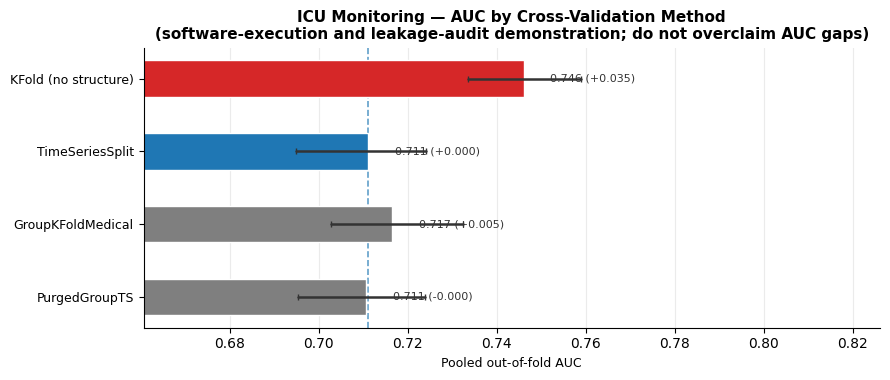


Summary Table — ICU Monitoring
Method                         AUC       SD    CI_lo    CI_hi   FLAG
-----------------------------------------------------------------
  KFold (no structure)       0.746    0.012    0.734    0.759   FLAG
  TimeSeriesSplit            0.711    0.113    0.695    0.724   PASS
  GroupKFoldMedical          0.717    0.054    0.703    0.732   PASS
  PurgedGroupTS              0.711    0.114    0.695    0.724   PASS

  AUC difference from K-Fold vs TimeSeriesSplit: +3.5 percentage points


In [9]:
plot_method_comparison(
    icu_results,
    title="ICU Monitoring — AUC by Cross-Validation Method\n"
          "(software-execution and leakage-audit demonstration; do not overclaim AUC gaps)",
    ref_key="TimeSeriesSplit"
)

# Print summary table
print("\nSummary Table — ICU Monitoring")
print(f"{'Method':<25} {'AUC':>8} {'SD':>8} {'CI_lo':>8} {'CI_hi':>8} {'FLAG':>6}")
print("-" * 65)
for name, res in icu_results.items():
    if res is None: continue
    flag = "FLAG" if res['flagged'] else "PASS"
    print(f"  {name.replace(chr(10),' '):<23} {res['auc']:>8.3f} {res['sd']:>8.3f} "
          f"{res['ci_lo']:>8.3f} {res['ci_hi']:>8.3f} {flag:>6}")

kfold_auc = icu_results["KFold\n(no structure)"]["auc"]
ts_auc    = icu_results["TimeSeriesSplit"]["auc"]
print(f"\n  AUC difference from K-Fold vs TimeSeriesSplit: "
      f"{(kfold_auc - ts_auc)*100:+.1f} percentage points")

## Cell 9 — Clinical Metrics with ClinicalMetrics

AUC alone is not enough for clinical decision-making.  
We also need **sensitivity** (how many sick patients we catch) and **specificity** (how many healthy we spare).

trustcv's `ClinicalMetrics` computes all of these with **Wilson 95% confidence intervals**.

In [10]:
# ── Clinical-style metrics from pooled out-of-fold predictions ───────────────
# This replaces the earlier UniversalCVRunner call so the notebook can run end-to-end.
# The goal is not a clinical benchmark; it is to show that the same fold outputs
# can be summarized using diagnostic quantities.

print("Clinical-style summary for ICU scenario")
print(f"{'Method':<35} {'AUC':>7} {'Patient AUC':>11} {'Se':>7} {'Sp':>7} {'Leakage':>9}")
print("-" * 82)
for name, res in icu_results.items():
    if res is None:
        continue
    patient_auc = "—" if np.isnan(res.get('patient_auc', np.nan)) else f"{res['patient_auc']:.3f}"
    flag = "FLAG" if res['flagged'] else "PASS"
    print(f"{name.replace(chr(10), ' '):<35} {res['auc']:>7.3f} {patient_auc:>11} {res['sensitivity']:>7.3f} {res['specificity']:>7.3f} {flag:>9}")

print("\nInterpretation: these diagnostic metrics are pooled out-of-fold summaries. They are suitable for illustration, not for making clinical performance claims from synthetic data.")


Clinical-style summary for ICU scenario
Method                                  AUC Patient AUC      Se      Sp   Leakage
----------------------------------------------------------------------------------
KFold (no structure)                  0.746       0.912   0.324   0.920      FLAG
TimeSeriesSplit                       0.711           —   0.358   0.861      PASS
GroupKFoldMedical                     0.717       0.877   0.316   0.910      PASS
PurgedGroupTS                         0.711       0.883   0.357   0.865      PASS

Interpretation: these diagnostic metrics are pooled out-of-fold summaries. They are suitable for illustration, not for making clinical performance claims from synthetic data.


---
# PART 2 — Disease Mapping: Spatial Data

## 🗺️ Clinical Context

Imagine you are modeling the **spatial distribution of a disease** across a region —  
for example, predicting which areas have high risk of an infectious disease outbreak,  
using environmental and demographic features from geographic locations.

### The spatial leakage problem

Geographic data has **spatial autocorrelation**: nearby locations tend to have similar values.  
If nearby points end up in both train and test, the model effectively "sees" the test area.

> **Key rule:** In spatial data, test locations must be geographically separated from training.

## Cell 10 — Generate Spatial Dataset

In [11]:
def generate_spatial_data(seed=42):
    """
    1,000 geocoded disease observations.
    Spatial dependence via Gaussian random field (exponential covariance).
    Nearby locations share similar disease risk.
    """
    rng = np.random.default_rng(seed)
    n   = 500

    # Random coordinates in a unit square [0,1] x [0,1]
    # Think of these as (longitude, latitude) scaled to [0,1]
    coords = rng.uniform(0, 1, (n, 2))

    # Exponential spatial covariance: corr(i,j) = exp(-dist(i,j) / length_scale)
    # Length scale 0.15 means locations within ~15% of the map are correlated
    length_scale = 0.15
    dists = np.sqrt(
        (coords[:, 0:1] - coords[:, 0]) ** 2 +
        (coords[:, 1:2] - coords[:, 1]) ** 2
    )
    cov = np.exp(-dists / length_scale) + np.eye(n) * 1e-6
    L   = np.linalg.cholesky(cov)  # Cholesky decomposition for sampling

    # Sample spatial field ("disease risk surface")
    rng2          = np.random.default_rng(seed + 100)
    spatial_field = L @ rng2.normal(0, 1, n)   # spatially correlated values

    # Normalize to [0,1] and threshold to get binary outcome
    ss = (spatial_field - spatial_field.min()) / (
         spatial_field.max() - spatial_field.min())
    y  = (ss + rng.normal(0, 0.25, n) > 0.58).astype(int)

    # Features: coordinates + spatial field + noise + spatial functions
    X = np.column_stack([
        coords,                                   # longitude, latitude
        spatial_field,                            # estimated spatial risk
        rng.normal(0, 1, (n, 5)),                 # environmental noise features
        np.sin(coords[:, 0] * np.pi * 2),        # spatial interaction feature
        np.cos(coords[:, 1] * np.pi * 2),
    ])
    return X, y, coords, spatial_field


X_spatial, y_spatial, coords_spatial, field_spatial = generate_spatial_data(seed=42)

print("=" * 50)
print("  SPATIAL EPIDEMIOLOGY DATASET")
print("=" * 50)
print(f"  Total locations    : {len(X_spatial):,}")
print(f"  Number of features : {X_spatial.shape[1]}")
print(f"  Spatial extent     : [{coords_spatial[:,0].min():.2f}, {coords_spatial[:,0].max():.2f}] × "
      f"[{coords_spatial[:,1].min():.2f}, {coords_spatial[:,1].max():.2f}]")
print(f"  Outcome balance    : {y_spatial.mean()*100:.1f}% high-risk locations")

df_sp = pd.DataFrame(X_spatial[:5, :4],
                     columns=["longitude", "latitude", "spatial_risk", "env_feature_1"]).round(3)
df_sp["outcome"] = y_spatial[:5]
print("\nSample rows:")
display(df_sp)

  SPATIAL EPIDEMIOLOGY DATASET
  Total locations    : 500
  Number of features : 10
  Spatial extent     : [0.00, 1.00] × [0.00, 1.00]
  Outcome balance    : 36.2% high-risk locations

Sample rows:


,longitude,latitude,spatial_risk,env_feature_1,outcome
0,0.774,0.439,-0.311,-1.360,0
1,0.859,0.697,-2.266,-0.013,0
2,0.094,0.976,-0.225,-1.457,0
3,0.761,0.786,-0.135,0.115,0
4,0.128,0.450,0.161,-1.373,0


## Cell 11 — Visualize Geographic Structure

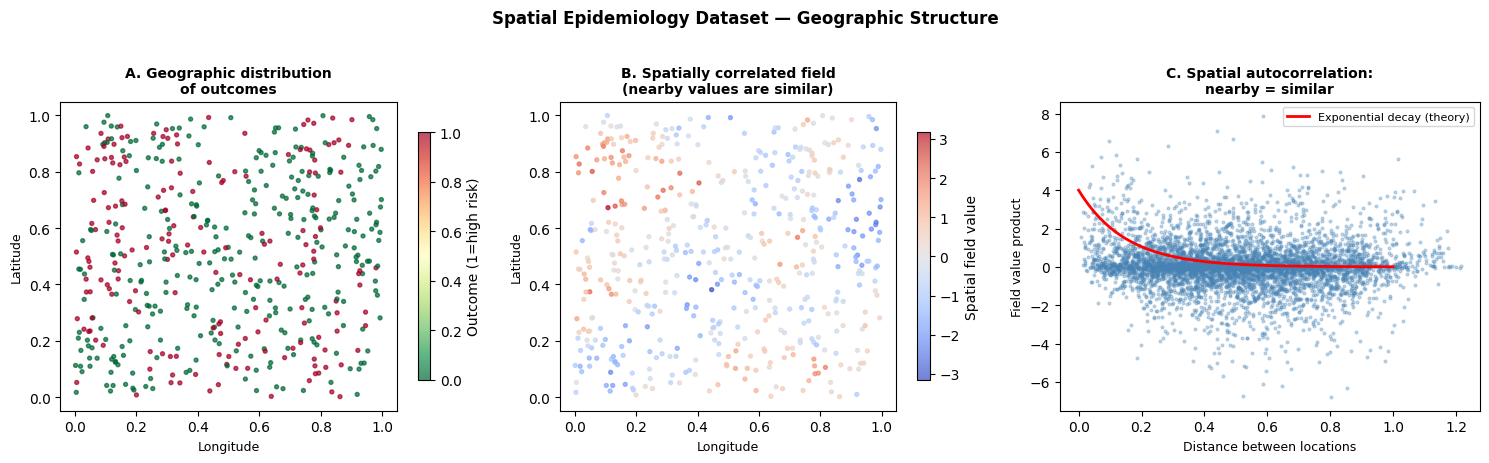


Key observations:
  1. Outcome is spatially clustered — high-risk areas are geographically grouped
  2. The spatial field shows clear geographic patterns
  3. Spatial autocorrelation decays with distance (as expected)
  → Random K-Fold splits will place nearby locations in both train and test


In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# Plot A: Geographic distribution of outcomes
scatter = axes[0].scatter(
    coords_spatial[:, 0], coords_spatial[:, 1],
    c=y_spatial, cmap="RdYlGn_r", s=8, alpha=0.7
)
plt.colorbar(scatter, ax=axes[0], label="Outcome (1=high risk)", shrink=0.8)
axes[0].set_xlabel("Longitude", fontsize=9)
axes[0].set_ylabel("Latitude", fontsize=9)
axes[0].set_title("A. Geographic distribution\nof outcomes", fontweight="bold", fontsize=10)

# Plot B: Spatial risk field
sc2 = axes[1].scatter(
    coords_spatial[:, 0], coords_spatial[:, 1],
    c=field_spatial, cmap="coolwarm", s=8, alpha=0.7
)
plt.colorbar(sc2, ax=axes[1], label="Spatial field value", shrink=0.8)
axes[1].set_xlabel("Longitude", fontsize=9)
axes[1].set_ylabel("Latitude", fontsize=9)
axes[1].set_title("B. Spatially correlated field\n(nearby values are similar)",
                  fontweight="bold", fontsize=10)

# Plot C: Spatial autocorrelation — distances vs. correlation
rng_vis   = np.random.default_rng(0)
idx_samp  = rng_vis.choice(len(coords_spatial), 200, replace=False)
c_samp    = coords_spatial[idx_samp]
f_samp    = field_spatial[idx_samp]
dist_flat = []
corr_flat = []
for i in range(len(idx_samp)):
    for j in range(i+1, min(i+30, len(idx_samp))):
        d = np.sqrt(((c_samp[i] - c_samp[j])**2).sum())
        dist_flat.append(d)
        corr_flat.append(f_samp[i] * f_samp[j])
dist_flat = np.array(dist_flat)
corr_flat = np.array(corr_flat)

axes[2].scatter(dist_flat, corr_flat, s=4, alpha=0.3, color="steelblue")
# Theoretical exponential decay
d_theory = np.linspace(0, 1, 100)
axes[2].plot(d_theory, 4 * np.exp(-d_theory / 0.15), "r-", lw=2,
             label="Exponential decay (theory)")
axes[2].set_xlabel("Distance between locations", fontsize=9)
axes[2].set_ylabel("Field value product", fontsize=9)
axes[2].set_title("C. Spatial autocorrelation:\nnearby = similar", fontweight="bold", fontsize=10)
axes[2].legend(fontsize=8)

plt.suptitle("Spatial Epidemiology Dataset — Geographic Structure",
             fontsize=12, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

print()
print("Key observations:")
print("  1. Outcome is spatially clustered — high-risk areas are geographically grouped")
print("  2. The spatial field shows clear geographic patterns")
print("  3. Spatial autocorrelation decays with distance (as expected)")
print("  → Random K-Fold splits will place nearby locations in both train and test")

## Cell 12 — Why K-Fold Fails on Spatial Data

The plot below shows how `SpatialBlockCV` divides the geographic region into blocks —  
each block becomes a test fold, and training uses all other blocks.

With K-Fold, train and test points are randomly scattered everywhere,  
so training points are always close to test points → **spatial leakage**.

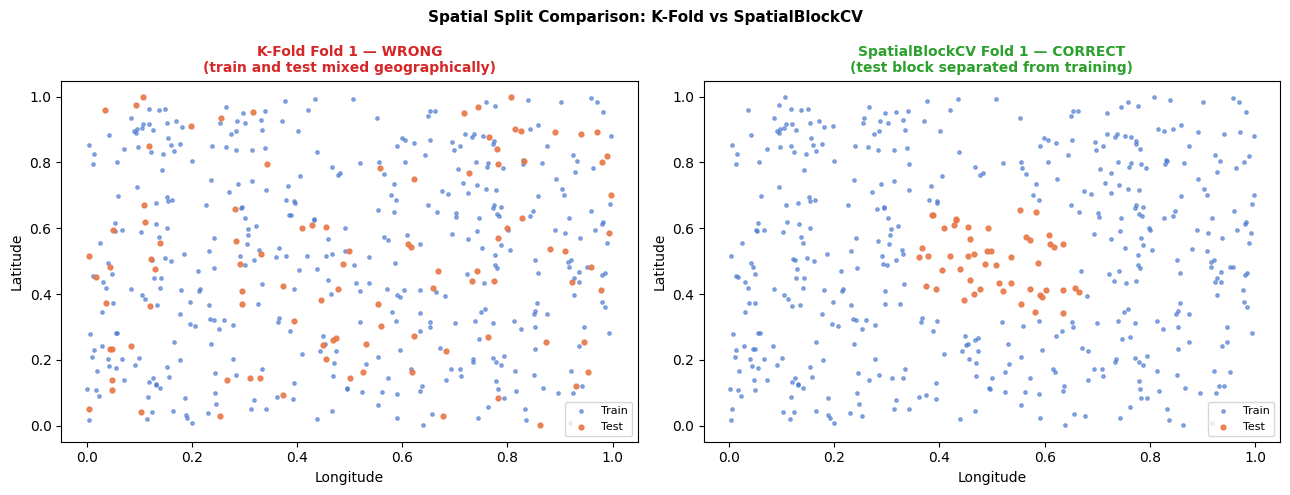


❌ K-Fold: Test points (orange) are scattered everywhere among train points (blue).
   Many test points have a neighbouring train point — spatial leakage!

✅ SpatialBlockCV: Test points form a compact geographic block.
   All training points are in a different part of the map.


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Left: K-Fold spatial assignment ───────────────────────────────────────────
kf_sp   = KFold(n_splits=5, shuffle=True, random_state=42)
splits_kf = list(kf_sp.split(X_spatial, y_spatial))
tr0, te0  = splits_kf[0]

axes[0].scatter(coords_spatial[tr0, 0], coords_spatial[tr0, 1],
                color="#4878CF", s=6, alpha=0.6, label="Train")
axes[0].scatter(coords_spatial[te0, 0], coords_spatial[te0, 1],
                color="#E87849", s=12, alpha=0.9, label="Test", zorder=3)
axes[0].set_title("K-Fold Fold 1 — WRONG\n(train and test mixed geographically)",
                  fontweight="bold", fontsize=10, color="#D62728")
axes[0].set_xlabel("Longitude"); axes[0].set_ylabel("Latitude")
axes[0].legend(fontsize=8)

# ── Right: SpatialBlockCV assignment ──────────────────────────────────────────
sb_cv     = SpatialBlockCV(n_splits=5, block_shape="grid", random_state=42)
splits_sb = list(sb_cv.split(X_spatial, y_spatial, coordinates=coords_spatial))
tr1, te1  = splits_sb[0]

axes[1].scatter(coords_spatial[tr1, 0], coords_spatial[tr1, 1],
                color="#4878CF", s=6, alpha=0.6, label="Train")
axes[1].scatter(coords_spatial[te1, 0], coords_spatial[te1, 1],
                color="#E87849", s=12, alpha=0.9, label="Test", zorder=3)
axes[1].set_title("SpatialBlockCV Fold 1 — CORRECT\n(test block separated from training)",
                  fontweight="bold", fontsize=10, color="#2CA02C")
axes[1].set_xlabel("Longitude"); axes[1].set_ylabel("Latitude")
axes[1].legend(fontsize=8)

plt.suptitle("Spatial Split Comparison: K-Fold vs SpatialBlockCV",
             fontsize=11, fontweight="bold")
plt.tight_layout()
plt.show()

print()
print("❌ K-Fold: Test points (orange) are scattered everywhere among train points (blue).")
print("   Many test points have a neighbouring train point — spatial leakage!")
print()
print("✅ SpatialBlockCV: Test points form a compact geographic block.")
print("   All training points are in a different part of the map.")

## Cell 13 — Run All Spatial Methods with trustcv

In [14]:
print("=" * 60)
print("  RUNNING: Spatial Epidemiology — Spatial CV Methods")
print("  trustcv DataLeakageChecker checking spatial_proximity")
print("=" * 60)
print()

spatial_results = {}

# ── Method 1: K-Fold (incorrect baseline) ─────────────────────────────────────
print("Method 1: KFold (incorrect baseline — random geographic mixing)")
spatial_results["KFold\n(no structure)"] = run_scenario(
    "KFold",
    KFold(n_splits=5, shuffle=True, random_state=42),
    X_spatial, y_spatial,
    leakage_coords=coords_spatial,   # check spatial proximity
    spatial_threshold=0.04,          # fixed map-scale threshold for audit
)

# ── Method 2: SpatialBlockCV ──────────────────────────────────────────────────
# Divides the geographic area into a grid.
# Each grid cell becomes a test set; training uses all other cells.
# block_shape='grid' creates rectangular blocks.
print("Method 2: SpatialBlockCV (grid-based geographic blocking)")
spatial_results["SpatialBlockCV"] = run_scenario(
    "SpatialBlockCV",
    SpatialBlockCV(n_splits=5, block_shape="grid", random_state=42),
    X_spatial, y_spatial,
    coords=coords_spatial,           # split by geographic block
    leakage_coords=coords_spatial,   # check spatial proximity
    spatial_threshold=0.04,          # fixed map-scale threshold for audit
)

# ── Method 3: BufferedSpatialCV ───────────────────────────────────────────────
# Like SpatialBlockCV but adds a buffer zone around test blocks.
# Training points within buffer_size of the test boundary are excluded.
# This prevents near-boundary leakage.
print("Method 3: BufferedSpatialCV (grid blocks + exclusion buffer)")
spatial_results["BufferedSpatialCV"] = run_scenario(
    "BufferedSpatialCV",
    BufferedSpatialCV(n_splits=5, buffer_size=0.12, random_state=42),
    X_spatial, y_spatial,
    coords=coords_spatial,           # split by geographic block + buffer
    leakage_coords=coords_spatial,   # check spatial proximity
    spatial_threshold=0.04,          # fixed map-scale threshold for audit
)

print("\nAll methods complete ✓")

  RUNNING: Spatial Epidemiology — Spatial CV Methods
  trustcv DataLeakageChecker checking spatial_proximity

Method 1: KFold (incorrect baseline — random geographic mixing)


  🚨 FLAG  KFold
         pooled OOF AUC = 0.712  95% CI [0.662, 0.751]
         fold AUC mean = 0.713 ± 0.048
         Se=0.392, Sp=0.846
         Structural leakage/audit flags: ['spatial_proximity']
         patient-overlap folds=0; temporal-violation folds=0
         mean spatial near fraction=0.856

Method 2: SpatialBlockCV (grid-based geographic blocking)


  🚨 FLAG  SpatialBlockCV
         pooled OOF AUC = 0.724  95% CI [0.670, 0.773]
         fold AUC mean = 0.691 ± 0.061
         Se=0.400, Sp=0.863
         Structural leakage/audit flags: ['spatial_proximity']
         patient-overlap folds=0; temporal-violation folds=0
         mean spatial near fraction=0.081

Method 3: BufferedSpatialCV (grid blocks + exclusion buffer)


  ✅ PASS  BufferedSpatialCV
         pooled OOF AUC = 0.674  95% CI [0.606, 0.729]
         fold AUC mean = 0.683 ± 0.051
         Se=0.409, Sp=0.820
         patient-overlap folds=0; temporal-violation folds=0
         mean spatial near fraction=0.000


All methods complete ✓


## Cell 14 — Visualize Buffered Spatial CV Block Structure

`BufferedSpatialCV` excludes training points near the test block boundary.  
This grey "buffer zone" prevents the model from learning patterns that are  
only valid right at the boundary between blocks.

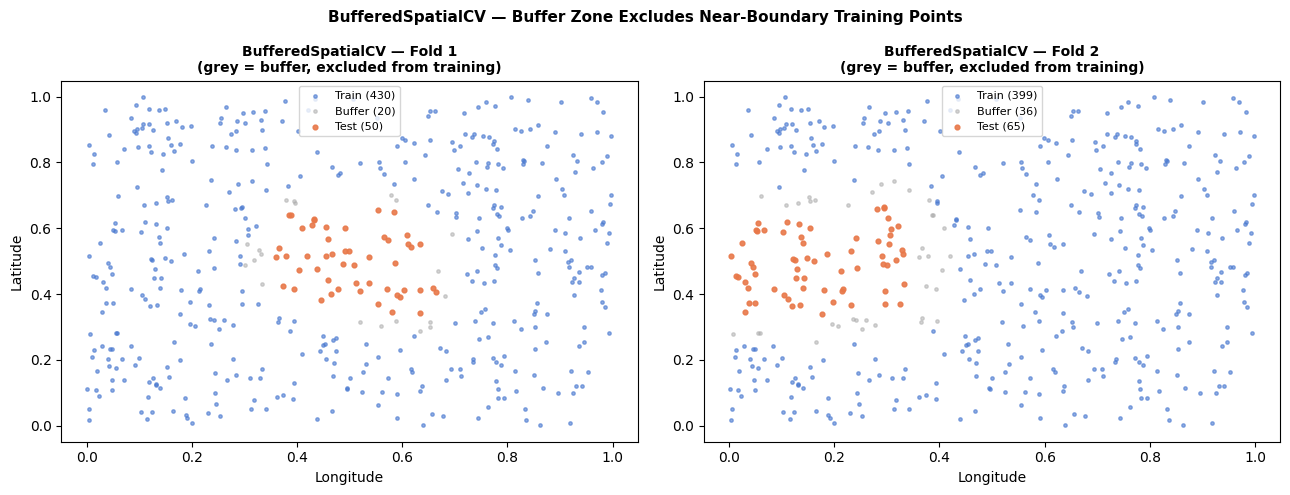


The buffer (grey) removes training points close to the test block.
This gives the most conservative and unbiased spatial estimate.
Trade-off: fewer training points → slightly lower AUC, but more honest.


In [15]:
# Show two folds of BufferedSpatialCV to illustrate the buffer zone
buf_cv     = BufferedSpatialCV(n_splits=5, buffer_size=0.12, random_state=42)
splits_buf = list(buf_cv.split(X_spatial, y_spatial, coordinates=coords_spatial))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax_i, (tr, te) in enumerate(splits_buf[:2]):
    ax = axes[ax_i]

    # All points not in train or test = buffer zone
    all_idx  = np.arange(len(X_spatial))
    buf_mask = ~np.isin(all_idx, np.concatenate([tr, te]))
    buf_idx  = all_idx[buf_mask]

    ax.scatter(coords_spatial[tr, 0],  coords_spatial[tr, 1],
               color="#4878CF", s=6,  alpha=0.6, label=f"Train ({len(tr)})")
    if len(buf_idx) > 0:
        ax.scatter(coords_spatial[buf_idx, 0], coords_spatial[buf_idx, 1],
                   color="#AAAAAA", s=6, alpha=0.5, label=f"Buffer ({len(buf_idx)})")
    ax.scatter(coords_spatial[te, 0],  coords_spatial[te, 1],
               color="#E87849", s=12, alpha=0.9, zorder=3,
               label=f"Test ({len(te)})")

    ax.set_title(f"BufferedSpatialCV — Fold {ax_i+1}\n"
                 f"(grey = buffer, excluded from training)",
                 fontweight="bold", fontsize=10)
    ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
    ax.legend(fontsize=8)

plt.suptitle("BufferedSpatialCV — Buffer Zone Excludes Near-Boundary Training Points",
             fontsize=11, fontweight="bold")
plt.tight_layout()
plt.show()

print()
print("The buffer (grey) removes training points close to the test block.")
print("This gives the most conservative and unbiased spatial estimate.")
print("Trade-off: fewer training points → slightly lower AUC, but more honest.")

## Cell 15 — Spatial leakage audit and comparison

The spatial scenario has one subtle but useful lesson:

- `KFold` mixes nearby train and test locations throughout the map, so it should be flagged.
- `SpatialBlockCV` separates test data into geographic blocks, which usually reduces proximity leakage, but points near block borders can still be close to training points in adjacent blocks.
- `BufferedSpatialCV` excludes a buffer zone around the test block, so it is the most conservative spatial design in this notebook.

Therefore, a `SpatialBlockCV` flag does not mean the splitter failed. It means the chosen spatial audit threshold is stricter than simple block separation. The buffer method shows how to remove the remaining near-boundary contamination.


Spatial leakage audit — first fold of each method

🚨 KFold (wrong)
   severity         : medium
   structural types : ['spatial_proximity']
   near_fraction    : 0.880 (fraction of test points with nearby train points)
   mean_min_dist    : 0.0241
   threshold        : 0.0400

🚨 SpatialBlockCV (block-based)
   severity         : low
   structural types : ['spatial_proximity']
   near_fraction    : 0.180 (fraction of test points with nearby train points)
   mean_min_dist    : 0.0858
   threshold        : 0.0400

✅ BufferedSpatialCV
   severity         : none
   structural types : none
   near_fraction    : 0.000 (fraction of test points with nearby train points)
   mean_min_dist    : 0.1206
   threshold        : 0.0400



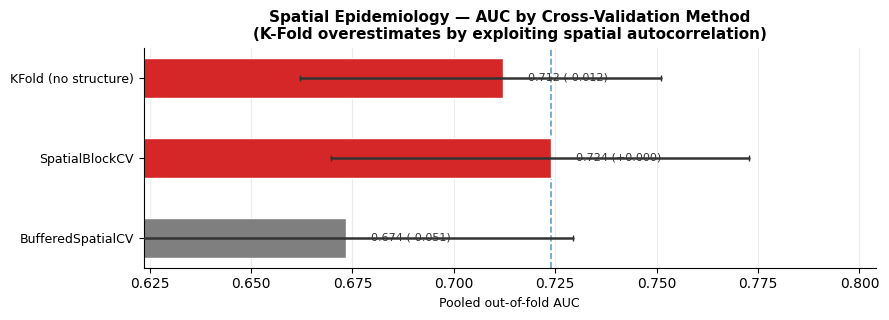

  AUC difference from K-Fold vs SpatialBlockCV: -1.2 percentage points


In [16]:
# ── Detailed leakage audit for spatial scenario ───────────────────────────────
checker = DataLeakageChecker(verbose=False)

print("Spatial leakage audit — first fold of each method")
print("=" * 55)

for method_name, sp in [
    ("KFold (wrong)",          KFold(n_splits=5, shuffle=True, random_state=42)),
    ("SpatialBlockCV (block-based)", SpatialBlockCV(n_splits=5, block_shape="grid", random_state=42)),
    ("BufferedSpatialCV",       BufferedSpatialCV(n_splits=5, buffer_size=0.12, random_state=42)),
]:
    if hasattr(sp, 'split'):
        try:
            splits = list(sp.split(X_spatial, y_spatial, coordinates=coords_spatial))
        except TypeError:
            splits = list(sp.split(X_spatial, y_spatial))

    tr, te = splits[0]

    report = checker.check_cv_splits(
        X_train           = X_spatial[tr],
        X_test            = X_spatial[te],
        y_train           = y_spatial[tr],
        y_test            = y_spatial[te],
        coordinates_train = coords_spatial[tr],  # spatial check
        coordinates_test  = coords_spatial[te],
        spatial_threshold = 0.04,
    )

    structural = sorted(set(report.leakage_types) & STRUCTURAL_TYPES)
    icon = "🚨" if structural else "✅"
    print(f"\n{icon} {method_name}")
    print(f"   severity         : {report.severity}")
    print(f"   structural types : {structural if structural else 'none'}")

    if "spatial_proximity" in report.details:
        sp_det = report.details["spatial_proximity"]
        print(f"   near_fraction    : {sp_det['near_fraction']:.3f} "
              f"(fraction of test points with nearby train points)")
        print(f"   mean_min_dist    : {sp_det['mean_min_distance']:.4f}")
        print(f"   threshold        : {sp_det['threshold']:.4f}")

print()

# ── Comparison plot ───────────────────────────────────────────────────────────
plot_method_comparison(
    spatial_results,
    title="Spatial Epidemiology — AUC by Cross-Validation Method\n"
          "(K-Fold overestimates by exploiting spatial autocorrelation)",
    ref_key="SpatialBlockCV",
)

kfold_auc = spatial_results["KFold\n(no structure)"]["auc"]
sb_auc    = spatial_results["SpatialBlockCV"]["auc"]
print(f"  AUC difference from K-Fold vs SpatialBlockCV: "
      f"{(kfold_auc - sb_auc)*100:+.1f} percentage points")

---
# PART 3 — Multisite Clinical Trial: Hierarchical Data

## 🏥 Clinical Context

A multisite clinical trial recruits patients from **10 hospitals**.  
Each patient has **2–4 visits** (repeated measurements).

The data has a **two-level hierarchy**:
```
Hospital  →  Patient  →  Visit
(site)        (group)    (observation)
```

### The hierarchical leakage problem

Standard K-Fold splits **visits randomly** — same patient's visits can appear in both train and test.  
Even if you use `GroupKFold` by patient, same *hospital* can be in both folds — site-level leakage.

Site effects are real: hospitals differ in equipment, protocols, patient populations.  
A model tested on the same hospitals it trained on will not generalise to new hospitals.

## Cell 16 — Generate Multisite Dataset

In [17]:
def generate_multisite_data(seed=42):
    """
    10 clinical sites, 50-100 patients per site, 2-4 observations per patient.
    Site-level random effects introduce hierarchical dependence.
    """
    rng = np.random.default_rng(seed)
    records, site_ids_list, patient_ids_list = [], [], []
    patient_outcomes = {}
    pid = 0

    for site in range(10):
        n_patients    = rng.integers(30, 51)    # 50-100 patients per site
        site_prev     = np.clip(0.35 + rng.uniform(-0.18, 0.18), 0.1, 0.65)
        site_fp       = rng.normal(site_prev * 1.2, 0.5, 2)  # site fingerprint

        for _ in range(n_patients):
            outcome = int(rng.random() < site_prev)
            patient_outcomes[pid] = outcome
            n_obs   = rng.integers(2, 5)          # 2-4 visits per patient
            p_fp    = rng.normal(outcome * 0.9, 0.5, 2)  # patient fingerprint

            for _ in range(n_obs):
                records.append([
                    site_fp[0] + p_fp[0] + rng.normal(0, 0.8),  # site+patient signal
                    site_fp[1] + rng.normal(0, 0.7),             # site effect
                    p_fp[1]    + rng.normal(0, 0.7),             # patient effect
                    rng.normal(outcome * 0.35, 0.9),             # outcome signal
                    rng.normal(outcome * 0.25, 1.0),
                    rng.normal(0, 1),                            # noise
                    float(site) / 10,                            # site index feature
                    rng.normal(outcome * 0.2, 1.0),
                ])
                site_ids_list.append(site)
                patient_ids_list.append(pid)
            pid += 1

    X      = np.array(records)
    y      = np.array([patient_outcomes[p] for p in patient_ids_list])
    s_ids  = np.array(site_ids_list)
    p_ids  = np.array(patient_ids_list)
    return X, y, s_ids, p_ids


X_ms, y_ms, site_ids, patient_ids_ms = generate_multisite_data(seed=42)

print("=" * 55)
print("  MULTISITE CLINICAL TRIAL DATASET")
print("=" * 55)
print(f"  Total observations  : {len(X_ms):,}")
print(f"  Number of hospitals : {len(np.unique(site_ids))}")
print(f"  Number of patients  : {len(np.unique(patient_ids_ms))}")
print(f"  Number of features  : {X_ms.shape[1]}")
print(f"  Obs per patient     : {len(X_ms)/len(np.unique(patient_ids_ms)):.1f} (average)")
print(f"  Outcome balance     : {y_ms.mean()*100:.1f}% positive")
print()

# Patients per site
print("  Patients per hospital:")
for s in np.unique(site_ids):
    n_pats = len(np.unique(patient_ids_ms[site_ids == s]))
    n_obs  = (site_ids == s).sum()
    print(f"    Hospital {s:2d}: {n_pats:3d} patients, {n_obs:4d} observations")

  MULTISITE CLINICAL TRIAL DATASET
  Total observations  : 1,227
  Number of hospitals : 10
  Number of patients  : 410
  Number of features  : 8
  Obs per patient     : 3.0 (average)
  Outcome balance     : 27.2% positive

  Patients per hospital:
    Hospital  0:  31 patients,   93 observations
    Hospital  1:  47 patients,  149 observations
    Hospital  2:  36 patients,  109 observations
    Hospital  3:  39 patients,  117 observations
    Hospital  4:  39 patients,  117 observations
    Hospital  5:  47 patients,  134 observations
    Hospital  6:  41 patients,  116 observations
    Hospital  7:  48 patients,  148 observations
    Hospital  8:  37 patients,  111 observations
    Hospital  9:  45 patients,  133 observations


## Cell 17 — Visualize Hospital Site Structure

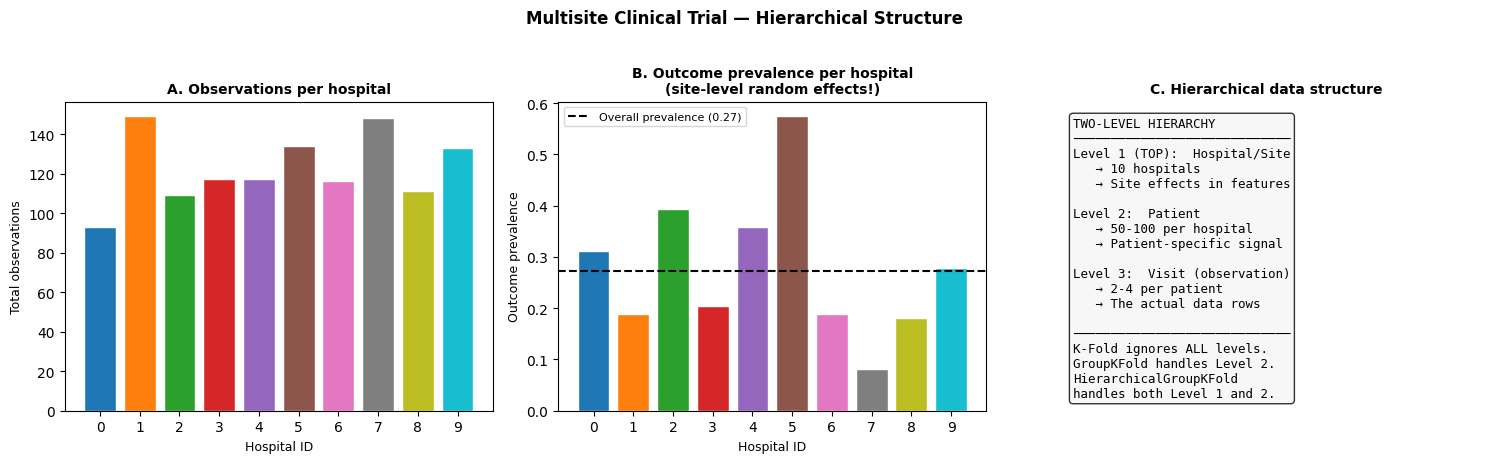


Key observation: Hospitals differ in outcome prevalence (plot B).
If train/test split at observation level, hospital effects will leak.
→ We need to split at patient OR hospital level, not visit level.


In [18]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

site_colors = plt.cm.tab10(np.linspace(0, 1, 10))

# Plot A: Observations per hospital
sites_unique = np.unique(site_ids)
obs_per_site = [(site_ids == s).sum() for s in sites_unique]
bars = axes[0].bar(sites_unique, obs_per_site,
                   color=site_colors, edgecolor="white")
axes[0].set_xlabel("Hospital ID", fontsize=9)
axes[0].set_ylabel("Total observations", fontsize=9)
axes[0].set_title("A. Observations per hospital", fontweight="bold", fontsize=10)
axes[0].set_xticks(sites_unique)

# Plot B: Outcome prevalence per hospital (site effect!)
prev_per_site = [y_ms[site_ids == s].mean() for s in sites_unique]
axes[1].bar(sites_unique, prev_per_site, color=site_colors, edgecolor="white")
axes[1].axhline(y_ms.mean(), color="black", ls="--",
                label=f"Overall prevalence ({y_ms.mean():.2f})")
axes[1].set_xlabel("Hospital ID", fontsize=9)
axes[1].set_ylabel("Outcome prevalence", fontsize=9)
axes[1].set_title("B. Outcome prevalence per hospital\n(site-level random effects!)",
                  fontweight="bold", fontsize=10)
axes[1].set_xticks(sites_unique)
axes[1].legend(fontsize=8)

# Plot C: Two-level hierarchy illustration
axes[2].axis("off")
hierarchy_text = (
    "TWO-LEVEL HIERARCHY\n"
    "─────────────────────────────\n"
    "Level 1 (TOP):  Hospital/Site\n"
    "   → 10 hospitals\n"
    "   → Site effects in features\n\n"
    "Level 2:  Patient\n"
    "   → 50-100 per hospital\n"
    "   → Patient-specific signal\n\n"
    "Level 3:  Visit (observation)\n"
    "   → 2-4 per patient\n"
    "   → The actual data rows\n\n"
    "─────────────────────────────\n"
    "K-Fold ignores ALL levels.\n"
    "GroupKFold handles Level 2.\n"
    "HierarchicalGroupKFold\n"
    "handles both Level 1 and 2."
)
axes[2].text(0.05, 0.95, hierarchy_text, transform=axes[2].transAxes,
             fontsize=9, va="top", family="monospace",
             bbox=dict(boxstyle="round", facecolor="#F5F5F5", alpha=0.8))
axes[2].set_title("C. Hierarchical data structure", fontweight="bold", fontsize=10)

plt.suptitle("Multisite Clinical Trial — Hierarchical Structure",
             fontsize=12, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

print()
print("Key observation: Hospitals differ in outcome prevalence (plot B).")
print("If train/test split at observation level, hospital effects will leak.")
print("→ We need to split at patient OR hospital level, not visit level.")

## Cell 18 — Run All Hierarchical Methods with trustcv

In [19]:
print("=" * 65)
print("  RUNNING: Multisite Clinical Trial — Hierarchical CV Methods")
print("  trustcv DataLeakageChecker enabled on every fold")
print("=" * 65)
print()

multisite_results = {}

# ── Method 1: K-Fold (incorrect baseline) ─────────────────────────────────────
print("Method 1: KFold (incorrect — splits visits randomly, ignores hierarchy)")
multisite_results["KFold\n(no structure)"] = run_scenario(
    "KFold",
    KFold(n_splits=5, shuffle=True, random_state=42),
    X_ms, y_ms,
    leakage_groups=patient_ids_ms,   # check patient overlap
)

# ── Method 2: GroupKFoldMedical (patient level) ───────────────────────────────
# Keeps all visits from the same patient together.
# Prevents patient-level leakage but NOT site-level leakage.
print("Method 2: GroupKFoldMedical (patient-level grouping)")
multisite_results["GroupKFoldMedical\n(patient)"] = run_scenario(
    "GroupKFoldMedical (patient)",
    GroupKFoldMedical(n_splits=5, random_state=42),
    X_ms, y_ms,
    groups=patient_ids_ms,           # split by patient
    leakage_groups=patient_ids_ms,   # check patient overlap
)

# ── Method 3: HierarchicalGroupKFold (site level) ────────────────────────────
# Splits at the SITE level — all patients from a given hospital go to same fold.
# This is the correct method for multi-site trial evaluation.
# It tests whether the model generalises to NEW hospitals.
print("Method 3: HierarchicalGroupKFold (site-level — most rigorous for multisite)")
multisite_results["HierarchicalGroupKFold\n(site)"] = run_scenario(
    "HierarchicalGroupKFold (site)",
    HierarchicalGroupKFold(n_splits=5, random_state=42),
    X_ms, y_ms,
    groups=site_ids,                 # split by hospital
    leakage_groups=patient_ids_ms,   # check patient overlap in each fold
)

# ── Method 4: LeaveOneGroupOut (site level) ───────────────────────────────────
# The strictest approach: each hospital is test set exactly once.
# Train on 9 hospitals, test on 1 — perfect generalization assessment.
# Note: gives 10 folds (one per hospital), which is more stable than K-Fold.
print("Method 4: LeaveOneGroupOut (leave-one-hospital-out — strictest evaluation)")
multisite_results["LeaveOneGroupOut\n(per site)"] = run_scenario(
    "LeaveOneGroupOut (per site)",
    LeaveOneGroupOut(),
    X_ms, y_ms,
    groups=site_ids,                 # leave one hospital out at a time
    leakage_groups=patient_ids_ms,   # check patient overlap
)

print("\nAll methods complete ✓")

  RUNNING: Multisite Clinical Trial — Hierarchical CV Methods
  trustcv DataLeakageChecker enabled on every fold

Method 1: KFold (incorrect — splits visits randomly, ignores hierarchy)


  🚨 FLAG  KFold
         pooled OOF AUC = 0.828  95% CI [0.800, 0.853]
         fold AUC mean = 0.831 ± 0.027
         patient-level AUC = 0.897
         Se=0.380, Sp=0.946
         Structural leakage/audit flags: ['patient']
         patient-overlap folds=5; temporal-violation folds=0

Method 2: GroupKFoldMedical (patient-level grouping)


  ✅ PASS  GroupKFoldMedical (patient)
         pooled OOF AUC = 0.812  95% CI [0.784, 0.836]
         fold AUC mean = 0.820 ± 0.016
         patient-level AUC = 0.877
         Se=0.344, Sp=0.940
         patient-overlap folds=0; temporal-violation folds=0

Method 3: HierarchicalGroupKFold (site-level — most rigorous for multisite)


  ✅ PASS  HierarchicalGroupKFold (site)
         pooled OOF AUC = 0.745  95% CI [0.715, 0.777]
         fold AUC mean = 0.804 ± 0.035
         patient-level AUC = 0.790
         Se=0.320, Sp=0.927
         patient-overlap folds=0; temporal-violation folds=0

Method 4: LeaveOneGroupOut (leave-one-hospital-out — strictest evaluation)


  ✅ PASS  LeaveOneGroupOut (per site)
         pooled OOF AUC = 0.764  95% CI [0.732, 0.796]
         fold AUC mean = 0.805 ± 0.070
         patient-level AUC = 0.820
         Se=0.329, Sp=0.934
         patient-overlap folds=0; temporal-violation folds=0


All methods complete ✓


## Cell 19 — Multisite Leakage Audit & Fold Structure Visualization

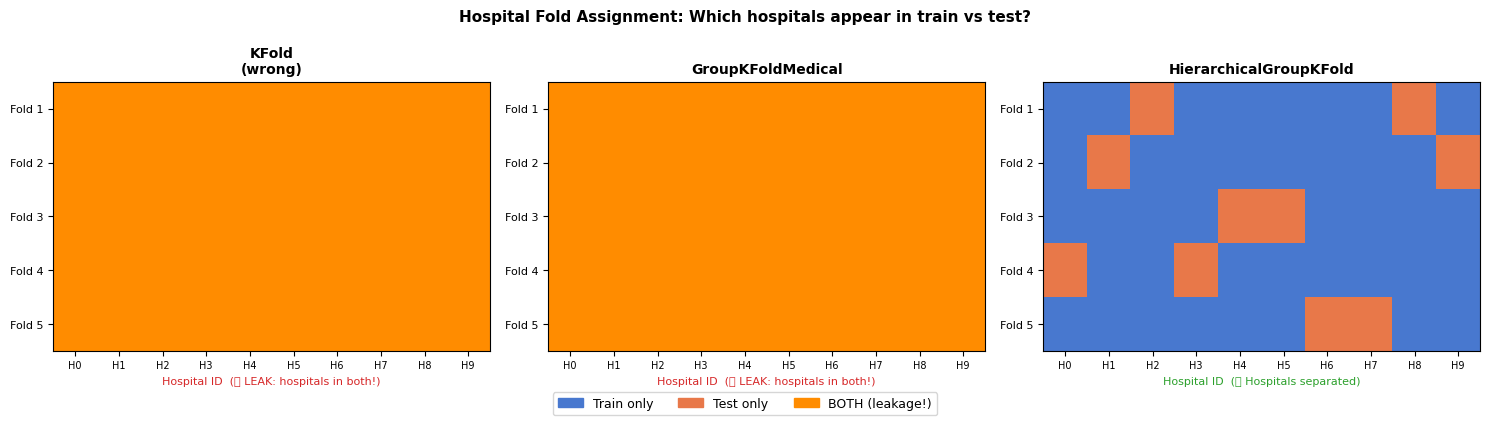


❌ KFold: Most hospitals appear in BOTH train and test (orange = leakage).
   The model sees hospital-specific patterns during training.

✅ GroupKFoldMedical: Patients are separated, but hospitals may still overlap.
✅ HierarchicalGroupKFold: Hospitals are completely separated per fold.


In [20]:
# ── Show which hospitals go to train vs test in each fold ─────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

methods_vis = [
    ("KFold\n(wrong)",       KFold(n_splits=5, shuffle=True, random_state=42), {}),
    ("GroupKFoldMedical",    GroupKFoldMedical(n_splits=5, random_state=42), {"groups": patient_ids_ms}),
    ("HierarchicalGroupKFold", HierarchicalGroupKFold(n_splits=5, random_state=42), {"groups": site_ids}),
]

for ax_i, (m_name, splitter, skw) in enumerate(methods_vis):
    splits = list(splitter.split(X_ms, y_ms, **skw))[:5]
    n_sites = 10
    site_mat = np.zeros((len(splits), n_sites))

    for fold_i, (tr, te) in enumerate(splits):
        train_sites = set(site_ids[tr].tolist())
        test_sites  = set(site_ids[te].tolist())
        for s in range(n_sites):
            if s in test_sites and s in train_sites:
                site_mat[fold_i, s] = 0.5   # leakage: in BOTH
            elif s in test_sites:
                site_mat[fold_i, s] = 1.0   # test only
            else:
                site_mat[fold_i, s] = 0.0   # train only

    cmap = mcolors.ListedColormap(["#4878CF", "#FF8C00", "#E87849"])
    axes[ax_i].imshow(site_mat, aspect="auto", cmap=cmap, vmin=0, vmax=1)
    axes[ax_i].set_xticks(range(n_sites))
    axes[ax_i].set_xticklabels([f"H{s}" for s in range(n_sites)], fontsize=7)
    axes[ax_i].set_yticks(range(len(splits)))
    axes[ax_i].set_yticklabels([f"Fold {i+1}" for i in range(len(splits))], fontsize=8)
    axes[ax_i].set_xlabel("Hospital ID", fontsize=9)
    axes[ax_i].set_title(m_name, fontweight="bold", fontsize=10)

    leak_count = (site_mat == 0.5).sum()
    color_label = "#D62728" if leak_count > 0 else "#2CA02C"
    axes[ax_i].set_xlabel(
        f"Hospital ID  ({'🚨 LEAK: hospitals in both!' if leak_count > 0 else '✅ Hospitals separated'})",
        fontsize=8, color=color_label
    )

legend_pats = [
    mpatches.Patch(color="#4878CF", label="Train only"),
    mpatches.Patch(color="#E87849", label="Test only"),
    mpatches.Patch(color="#FF8C00", label="BOTH (leakage!)"),
]
fig.legend(handles=legend_pats, loc="lower center", ncol=3, fontsize=9,
           bbox_to_anchor=(0.5, -0.05))
plt.suptitle("Hospital Fold Assignment: Which hospitals appear in train vs test?",
             fontsize=11, fontweight="bold")
plt.tight_layout()
plt.show()

print()
print("❌ KFold: Most hospitals appear in BOTH train and test (orange = leakage).")
print("   The model sees hospital-specific patterns during training.")
print()
print("✅ GroupKFoldMedical: Patients are separated, but hospitals may still overlap.")
print("✅ HierarchicalGroupKFold: Hospitals are completely separated per fold.")

## Cell 20 — Multisite Leakage Audit & Comparison Plot

Hierarchical leakage audit — checking first 3 folds per method

── KFold (wrong) ──
   Fold 1: 🚨  severity=critical  patient_overlap=197  types=['patient']
   Fold 2: 🚨  severity=critical  patient_overlap=185  types=['patient']
   Fold 3: 🚨  severity=critical  patient_overlap=196  types=['patient']
   → ⚠️ Structural leakage detected

── GroupKFoldMedical ──
   Fold 1: ✅  severity=none      patient_overlap=0  types=none
   Fold 2: ✅  severity=none      patient_overlap=0  types=none
   Fold 3: ✅  severity=none      patient_overlap=0  types=none
   → All folds passed ✓

── HierarchicalGroupKFold ──
   Fold 1: ✅  severity=none      patient_overlap=0  types=none
   Fold 2: ✅  severity=none      patient_overlap=0  types=none
   Fold 3: ✅  severity=low       patient_overlap=0  types=none
   → All folds passed ✓

── LeaveOneGroupOut ──
   Fold 1: ✅  severity=none      patient_overlap=0  types=none
   Fold 2: ✅  severity=none      patient_overlap=0  types=none
   Fold 3: ✅  severity=none      

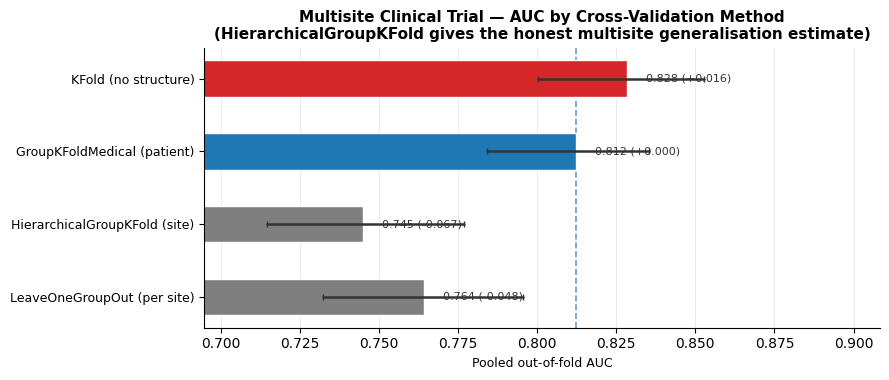

  AUC difference from K-Fold vs HierarchicalGroupKFold: +8.3 percentage points


In [21]:
# ── Per-fold DataLeakageChecker audit ─────────────────────────────────────────
checker = DataLeakageChecker(verbose=False)

print("Hierarchical leakage audit — checking first 3 folds per method")
print("=" * 60)

for m_name, splitter, skw in [
    ("KFold (wrong)",           KFold(n_splits=5, shuffle=True, random_state=42), {}),
    ("GroupKFoldMedical",       GroupKFoldMedical(n_splits=5, random_state=42), {"groups": patient_ids_ms}),
    ("HierarchicalGroupKFold",  HierarchicalGroupKFold(n_splits=5, random_state=42), {"groups": site_ids}),
    ("LeaveOneGroupOut",        LeaveOneGroupOut(), {"groups": site_ids}),
]:
    splits = list(splitter.split(X_ms, y_ms, **skw))[:3]
    print(f"\n── {m_name} ──")
    all_pass = True
    for fold_i, (tr, te) in enumerate(splits):
        report = checker.check_cv_splits(
            X_train           = np.zeros((1, 1)), X_test   = np.ones((1, 1)),
            y_train           = y_ms[tr], y_test   = y_ms[te],
            patient_ids_train = patient_ids_ms[tr],
            patient_ids_test  = patient_ids_ms[te],
        )
        structural = sorted(set(report.leakage_types) & STRUCTURAL_TYPES)
        icon   = "✅" if not structural else "🚨"
        n_overlap = report.details.get("patient_leakage", {}).get("overlap_count", 0)
        print(f"   Fold {fold_i+1}: {icon}  severity={report.severity:<8}  "
              f"patient_overlap={n_overlap}  types={structural if structural else 'none'}")
        if structural:
            all_pass = False
    print(f"   → {'All folds passed ✓' if all_pass else '⚠️ Structural leakage detected'}")

print()

# ── Comparison plot ───────────────────────────────────────────────────────────
plot_method_comparison(
    multisite_results,
    title="Multisite Clinical Trial — AUC by Cross-Validation Method\n"
          "(HierarchicalGroupKFold gives the honest multisite generalisation estimate)",
    ref_key="GroupKFoldMedical\n(patient)",
)

kfold_auc   = multisite_results["KFold\n(no structure)"]["auc"]
hier_auc    = multisite_results["HierarchicalGroupKFold\n(site)"]["auc"]
print(f"  AUC difference from K-Fold vs HierarchicalGroupKFold: "
      f"{(kfold_auc - hier_auc)*100:+.1f} percentage points")

---
# PART 4 — Final Comparison Across All Scenarios

## Cell 21 — Side-by-Side Comparison: All Three Scenarios

This final comparison shows the key message of this notebook:  
**K-Fold consistently overestimates AUC** when data has structure.  
The magnitude of inflation depends on how strong the structure is.

In [22]:
# 3-panel Plotly comparison figure
import os
import plotly.io as pio
from IPython.display import HTML, display
from pathlib import Path

# Colab and VS Code sometimes need an explicit renderer. The HTML display below
# is the most reliable inline path, and the saved HTML file is a fallback.
_ip = get_ipython() if "get_ipython" in globals() else None
if _ip is not None and "google.colab" in str(_ip):
    pio.renderers.default = "colab"
elif os.environ.get("VSCODE_PID"):
    pio.renderers.default = "vscode"
else:
    pio.renderers.default = "notebook_connected"

OUTPUT_DIR = Path("notebook_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

def make_plotly_panel(results_dict, panel_title, ref_key=None):
    keys = [k for k, v in results_dict.items() if v]
    if not keys:
        raise ValueError(f"No results available for {panel_title}. Run the scenario result cells before plotting.")

    names  = [k.replace("\n", " ") for k in keys]
    aucs   = [results_dict[k]["auc"]     for k in keys]
    ci_los = [results_dict[k]["ci_lo"]   for k in keys]
    ci_his = [results_dict[k]["ci_hi"]   for k in keys]
    flags  = [results_dict[k]["flagged"] for k in keys]

    colors = []
    for k, f in zip(keys, flags):
        if f:                                  colors.append("#D62728")
        elif ref_key and k == ref_key:         colors.append("#1F77B4")
        else:                                  colors.append("#7F7F7F")

    error_x = dict(
        type="data",
        symmetric=False,
        array=[hi - a for hi, a in zip(ci_his, aucs)],
        arrayminus=[a - lo for a, lo in zip(aucs, ci_los)],
    )

    return go.Bar(
        y=names, x=aucs, orientation="h",
        marker_color=colors,
        error_x=error_x,
        name=panel_title,
        text=[f"{'FLAG' if f else 'PASS'}" for f in flags],
        textposition="inside",
        textfont=dict(color="white", size=9),
        hovertemplate="%{y}<br>AUC=%{x:.3f}<extra></extra>",
    )


fig = make_subplots(
    rows=1, cols=3,
    subplot_titles=[
        "S3A: ICU Monitoring (Temporal)",
        "S3B: Spatial Epidemiology (Spatial)",
        "S3C: Multisite Clinical Trial (Hierarchical)",
    ],
    horizontal_spacing=0.12,
)

fig.add_trace(make_plotly_panel(icu_results, "ICU",
                                ref_key="PurgedGroupTS"), row=1, col=1)
fig.add_trace(make_plotly_panel(spatial_results, "Spatial",
                                ref_key="BufferedSpatialCV"), row=1, col=2)
fig.add_trace(make_plotly_panel(multisite_results, "Multisite",
                                ref_key="HierarchicalGroupKFold\n(site)"), row=1, col=3)

fig.update_xaxes(range=[0.48, 0.96], title_text="AUC")
fig.update_layout(
    title=dict(
        text="<b>Supplementary Figure S3 - Structured CV Scenario AUC Summaries</b><br>"
             "<sup>RED = FLAG (structural leakage detected by DataLeakageChecker)  "
             "BLUE = Structure-aware reference  GREY = PASS</sup>",
        x=0.5, font_size=13,
    ),
    height=420, width=1100,
    showlegend=False,
    plot_bgcolor="white",
    paper_bgcolor="white",
)

html_path = OUTPUT_DIR / "supplementary_figure_s3_auc.html"
fig.write_html(html_path, include_plotlyjs=True, full_html=True)

# Inline display for notebooks. If your frontend blocks Plotly JS, open the saved HTML file.
if pio.renderers.default == "vscode":
    fig.show(renderer="vscode")
else:
    display(HTML(fig.to_html(full_html=False, include_plotlyjs="cdn")))
print()
print(f"Interactive plot saved to: {html_path}")
print("Hover over bars to see exact AUC values and CI.")



Interactive plot saved to: notebook_outputs/supplementary_figure_s3_auc.html
Hover over bars to see exact AUC values and CI.


## Cell 22 — Per-fold AUC Distribution (Fold Stability)

Good CV is not just about the mean AUC — it also matters whether results are **stable across folds**.  
A high standard deviation means the model performs very differently in different folds → low reliability.

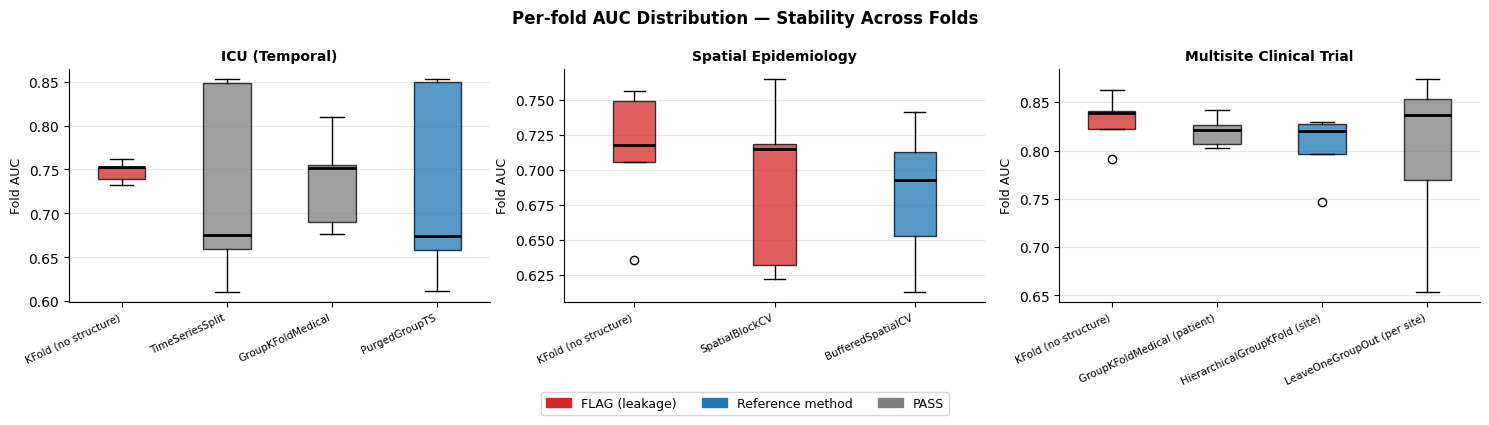


A narrow box = stable (consistent across folds) = more reliable estimate.
A wide box = high variance = less reliable — use repeated CV to reduce this.


In [23]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

scenario_data = [
    ("ICU (Temporal)",           icu_results,        "PurgedGroupTS"),
    ("Spatial Epidemiology",     spatial_results,     "BufferedSpatialCV"),
    ("Multisite Clinical Trial", multisite_results,   "HierarchicalGroupKFold\n(site)"),
]

for ax_i, (scenario_name, results, ref_key) in enumerate(scenario_data):
    ax = axes[ax_i]
    positions = []
    all_folds = []
    colors    = []
    labels    = []

    for i, (name, res) in enumerate(results.items()):
        if res is None: continue
        fold_aucs = res.get("fold_aucs", [])
        if not fold_aucs: continue
        positions.append(i)
        all_folds.append(fold_aucs)
        labels.append(name.replace("\n", " "))
        if res["flagged"]:               colors.append("#D62728")
        elif name == ref_key:            colors.append("#1F77B4")
        else:                            colors.append("#7F7F7F")

    bp = ax.boxplot(all_folds, vert=True, patch_artist=True,
                    medianprops=dict(color="black", linewidth=2))
    for patch, color in zip(bp["boxes"], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.75)

    ax.set_xticklabels(labels, rotation=25, ha="right", fontsize=7.5)
    ax.set_ylabel("Fold AUC", fontsize=9)
    ax.set_title(scenario_name, fontweight="bold", fontsize=10)
    ax.grid(axis="y", alpha=0.3)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.suptitle("Per-fold AUC Distribution — Stability Across Folds",
             fontsize=12, fontweight="bold")
legend_patches = [
    mpatches.Patch(color="#D62728", label="FLAG (leakage)"),
    mpatches.Patch(color="#1F77B4", label="Reference method"),
    mpatches.Patch(color="#7F7F7F", label="PASS"),
]
fig.legend(handles=legend_patches, loc="lower center", ncol=3,
           fontsize=9, bbox_to_anchor=(0.5, -0.05))
plt.tight_layout()
plt.show()

print()
print("A narrow box = stable (consistent across folds) = more reliable estimate.")
print("A wide box = high variance = less reliable — use repeated CV to reduce this.")


## Cell 23 — Final Summary Table

This table brings together all results from all three scenarios.  
It shows the AUC inflation caused by K-Fold in each scenario.

In [24]:
# ── Build final summary DataFrame ─────────────────────────────────────────────
rows = []

# Reference methods are chosen as the most structure-aware strategy in each scenario.
scenario_ref = {
    "ICU Monitoring (Temporal)":           (icu_results,       "PurgedGroupTS"),
    "Spatial Epidemiology (Spatial)":      (spatial_results,   "BufferedSpatialCV"),
    "Multisite Clinical Trial (Hierarch.)":(multisite_results, "HierarchicalGroupKFold\n(site)"),
}

for scenario_name, (results, ref_key) in scenario_ref.items():
    ref_auc = results[ref_key]["auc"] if results.get(ref_key) else None

    for name, res in results.items():
        if res is None:
            continue
        delta = (res["auc"] - ref_auc) if ref_auc is not None else np.nan
        rows.append({
            "Scenario": scenario_name,
            "Method": name.replace("\n", " "),
            "Pooled OOF AUC": f"{res['auc']:.3f}",
            "95% CI": f"[{res['ci_lo']:.3f}, {res['ci_hi']:.3f}]",
            "Fold AUC mean ± SD": f"{res.get('fold_auc_mean', np.nan):.3f} ± {res['sd']:.3f}",
            "Patient-level AUC": "—" if np.isnan(res.get('patient_auc', np.nan)) else f"{res['patient_auc']:.3f}",
            "Se": f"{res.get('sensitivity', np.nan):.3f}",
            "Sp": f"{res.get('specificity', np.nan):.3f}",
            "ΔAUC vs reference": "Ref" if name == ref_key else f"{delta:+.3f}",
            "Patient-overlap folds": res.get("patient_overlap_folds", 0),
            "Temporal-violation folds": res.get("temporal_violation_folds", 0),
            "Spatial near fraction": "—" if np.isnan(res.get('spatial_near_fraction', np.nan)) else f"{res['spatial_near_fraction']:.3f}",
            "Leakage audit": "FLAG" if res["flagged"] else "PASS",
        })

df_summary = pd.DataFrame(rows)

OUTPUT_DIR = Path("notebook_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)
summary_csv = OUTPUT_DIR / "supplementary_table_s3_structured_scenarios.csv"
summary_md = OUTPUT_DIR / "supplementary_table_s3_structured_scenarios.md"
df_summary.to_csv(summary_csv, index=False)
df_summary.to_markdown(summary_md, index=False)

print("FINAL SUMMARY TABLE — Structured scenario execution and leakage-audit demonstration")
print("Saved:", summary_csv)
print("Saved:", summary_md)
print()
display(df_summary)

print()
print("Notebook take-home messages:")
print("  1. Temporal, spatial, and hierarchical splitters are exercised in executable examples.")
print("  2. The leakage checker audits structural violations fold by fold.")
print("  3. AUC values are illustrative because all datasets are synthetic; do not treat them as clinical benchmarks.")
print("  4. The ICU example separates temporal-only, patient-only, and hybrid temporal-grouped validation logic.")
print("  5. The spatial example shows that buffering can be needed when simple block separation leaves near-boundary proximity.")

# Compact table for manuscript/supplement use.
compact_df = pd.DataFrame([
    {
        "Scenario": "ICU temporal monitoring",
        "Incorrect baseline": "KFold",
        "Methods exercised": "TimeSeriesSplit; GroupKFoldMedical; PurgedGroupTimeSeriesSplit",
        "Structural constraint shown": "Temporal order, purge gap, patient exclusivity",
        "Main interpretation": "Temporal-only and patient-only validation solve different problems; the hybrid splitter handles both.",
    },
    {
        "Scenario": "Spatial epidemiology",
        "Incorrect baseline": "KFold",
        "Methods exercised": "SpatialBlockCV; BufferedSpatialCV",
        "Structural constraint shown": "Geographic blocks and buffer exclusion",
        "Main interpretation": "Spatial blocking reduces geographic mixing; buffering removes remaining near-boundary proximity.",
    },
    {
        "Scenario": "Multisite clinical trial",
        "Incorrect baseline": "KFold",
        "Methods exercised": "GroupKFoldMedical; HierarchicalGroupKFold; LeaveOneGroupOut",
        "Structural constraint shown": "Patient-level and site-level exclusivity",
        "Main interpretation": "Patient-level validation and new-site validation answer different generalization questions.",
    },
])
compact_csv = OUTPUT_DIR / "compact_structured_scenarios.csv"
compact_md = OUTPUT_DIR / "compact_structured_scenarios.md"
compact_df.to_csv(compact_csv, index=False)
compact_df.to_markdown(compact_md, index=False)

print("\nCompact scenario table:")
display(compact_df)
print("Saved:", compact_csv)
print("Saved:", compact_md)


FINAL SUMMARY TABLE — Structured scenario execution and leakage-audit demonstration
Saved: notebook_outputs/supplementary_table_s3_structured_scenarios.csv
Saved: notebook_outputs/supplementary_table_s3_structured_scenarios.md



,Scenario,Method,Pooled OOF AUC,95% CI,Fold AUC mean ± SD,Patient-level AUC,Se,Sp,ΔAUC vs reference,Patient-overlap folds,Temporal-violation folds,Spatial near fraction,Leakage audit
0,ICU Monitoring (Temporal),KFold (no structure),0.746,"[0.734, 0.759]",0.748 ± 0.012,0.912,0.324,0.920,+0.035,5,5,—,FLAG
1,ICU Monitoring (Temporal),TimeSeriesSplit,0.711,"[0.695, 0.724]",0.729 ± 0.113,—,0.358,0.861,+0.000,0,0,—,PASS
2,ICU Monitoring (Temporal),GroupKFoldMedical,0.717,"[0.703, 0.732]",0.737 ± 0.054,0.877,0.316,0.910,+0.006,0,0,—,PASS
3,ICU Monitoring (Temporal),PurgedGroupTS,0.711,"[0.695, 0.724]",0.729 ± 0.114,0.883,0.357,0.865,Ref,0,0,—,PASS
4,Spatial Epidemiology (Spatial),KFold (no structure),0.712,"[0.662, 0.751]",0.713 ± 0.048,—,0.392,0.846,+0.039,0,0,0.856,FLAG
5,Spatial Epidemiology (Spatial),SpatialBlockCV,0.724,"[0.670, 0.773]",0.691 ± 0.061,—,0.400,0.863,+0.051,0,0,0.081,FLAG
6,Spatial Epidemiology (Spatial),BufferedSpatialCV,0.674,"[0.606, 0.729]",0.683 ± 0.051,—,0.409,0.820,Ref,0,0,0.000,PASS
7,Multisite Clinical Trial (Hierarch.),KFold (no structure),0.828,"[0.800, 0.853]",0.831 ± 0.027,0.897,0.380,0.946,+0.083,5,0,—,FLAG
8,Multisite Clinical Trial (Hierarch.),GroupKFoldMedical (patient),0.812,"[0.784, 0.836]",0.820 ± 0.016,0.877,0.344,0.940,+0.067,0,0,—,PASS
9,Multisite Clinical Trial (Hierarch.),HierarchicalGroupKFold (site),0.745,"[0.715, 0.777]",0.804 ± 0.035,0.790,0.320,0.927,Ref,0,0,—,PASS



Notebook take-home messages:
  1. Temporal, spatial, and hierarchical splitters are exercised in executable examples.
  2. The leakage checker audits structural violations fold by fold.
  3. AUC values are illustrative because all datasets are synthetic; do not treat them as clinical benchmarks.
  4. The ICU example separates temporal-only, patient-only, and hybrid temporal-grouped validation logic.
  5. The spatial example shows that buffering can be needed when simple block separation leaves near-boundary proximity.

Compact scenario table:


,Scenario,Incorrect baseline,Methods exercised,Structural constraint shown,Main interpretation
0,ICU temporal monitoring,KFold,TimeSeriesSplit; GroupKFoldMedical; PurgedGrou...,"Temporal order, purge gap, patient exclusivity",Temporal-only and patient-only validation solv...
1,Spatial epidemiology,KFold,SpatialBlockCV; BufferedSpatialCV,Geographic blocks and buffer exclusion,Spatial blocking reduces geographic mixing; bu...
2,Multisite clinical trial,KFold,GroupKFoldMedical; HierarchicalGroupKFold; Lea...,Patient-level and site-level exclusivity,Patient-level validation and new-site validati...


Saved: notebook_outputs/compact_structured_scenarios.csv
Saved: notebook_outputs/compact_structured_scenarios.md


## Cell 24 — Decision Guide: Which trustcv Splitter to Use?

Use this decision tree to select the right splitter for your medical ML project:

In [25]:
decision_text = """
╔══════════════════════════════════════════════════════════════════════╗
║             trustcv SPLITTER SELECTION GUIDE                        ║
╠══════════════════════════════════════════════════════════════════════╣
║                                                                      ║
║  Q1: Does your dataset have REPEATED MEASUREMENTS per patient?       ║
║      (e.g., multiple visits, scans, or time-points per patient)      ║
║                                                                      ║
║  YES ─────────────────────────────────────────────────────────────── ║
║  │                                                                   ║
║  │  Q2: Is the data LONGITUDINAL / TIME-ORDERED?                     ║
║  │                                                                   ║
║  │  YES → use PurgedGroupTimeSeriesSplit                             ║
║  │         (temporal forward-chaining + patient grouping + purge)    ║
║  │                                                                   ║
║  │  NO  → Q3: Multi-site / multi-hospital?                          ║
║  │                                                                   ║
║  │        YES → use HierarchicalGroupKFold  (split at site level)   ║
║  │             or LeaveOneGroupOut          (strictest option)       ║
║  │                                                                   ║
║  │        NO  → use GroupKFoldMedical       (standard patient CV)   ║
║  │             or StratifiedGroupKFold      (if class imbalance)    ║
║  │             or RepeatedGroupKFold        (if need lower variance) ║
║                                                                      ║
║  NO ──────────────────────────────────────────────────────────────── ║
║  │                                                                   ║
║  │  Q2: Does your data have GEOGRAPHIC COORDINATES?                  ║
║  │                                                                   ║
║  │  YES → use SpatialBlockCV     (standard geographic blocking)     ║
║  │         or BufferedSpatialCV  (blocking + boundary buffer)        ║
║  │                                                                   ║
║  │  NO  → Q3: Is data TIME-ORDERED (single observation per time)?   ║
║  │                                                                   ║
║  │        YES → use TimeSeriesSplit      (forward-chaining)         ║
║  │              or BlockedTimeSeries     (non-overlapping blocks)    ║
║  │              or PurgedKFoldCV         (K-fold + purge gap)        ║
║  │                                                                   ║
║  │        NO  → STANDARD IID METHODS (no structure detected)        ║
║  │              use StratifiedKFold (recommended default)           ║
║  │              or RepeatedKFold    (lower variance)                ║
║  │              or NestedCV         (if you also tune hyperparams)  ║
║                                                                      ║
╠══════════════════════════════════════════════════════════════════════╣
║  ⚠️  ALWAYS enable DataLeakageChecker (it is ON by default in       ║
║      trustcv — disable only with check_leakage=False if needed)      ║
╚══════════════════════════════════════════════════════════════════════╝
"""

print(decision_text)

print()
print("Quick reference — trustcv imports for structured CV:")
print()
print("  # For repeated-measures patient data:")
print("  from trustcv import GroupKFoldMedical, HierarchicalGroupKFold, LeaveOneGroupOut")
print()
print("  # For time-series or temporal data:")
print("  from trustcv.splitters import TimeSeriesSplit, PurgedGroupTimeSeriesSplit")
print()
print("  # For geographic / spatial data:")
print("  from trustcv.splitters import SpatialBlockCV, BufferedSpatialCV")
print()
print("  # Leakage detection (always use):")
print("  from trustcv import DataLeakageChecker")
print("  checker = DataLeakageChecker()")
print("  report  = checker.check_cv_splits(X_train, X_test, y_train, y_test,")
print("                patient_ids_train=..., timestamps_train=..., ...)")
print("  print(report.summary)  # ✅ No leakage  or  ⚠️ Leakage detected")


╔══════════════════════════════════════════════════════════════════════╗
║             trustcv SPLITTER SELECTION GUIDE                        ║
╠══════════════════════════════════════════════════════════════════════╣
║                                                                      ║
║  Q1: Does your dataset have REPEATED MEASUREMENTS per patient?       ║
║      (e.g., multiple visits, scans, or time-points per patient)      ║
║                                                                      ║
║  YES ─────────────────────────────────────────────────────────────── ║
║  │                                                                   ║
║  │  Q2: Is the data LONGITUDINAL / TIME-ORDERED?                     ║
║  │                                                                   ║
║  │  YES → use PurgedGroupTimeSeriesSplit                             ║
║  │         (temporal forward-chaining + patient grouping + purge)    ║
║  │                                               

---

## Notebook summary

This notebook demonstrates that `trustcv` can operationalize structure-aware cross-validation beyond the grouped synthetic benchmark.

### Main lessons

| Data structure | Problem with ordinary K-Fold | Structure-aware options shown here |
|---|---|---|
| Temporal ICU monitoring | train/test windows are mixed across time; repeated patient records can overlap | `TimeSeriesSplit`, `GroupKFoldMedical`, `PurgedGroupTimeSeriesSplit` |
| Spatial epidemiology | nearby train and test locations can share autocorrelated information | `SpatialBlockCV`, `BufferedSpatialCV` |
| Multisite clinical trial | visits, patients, and hospitals can be split at the wrong level | `GroupKFoldMedical`, `HierarchicalGroupKFold`, `LeaveOneGroupOut` |

### Safe interpretation

The notebook is an **illustrative execution check**. It shows that the splitters run, the fold structure is auditable, and the leakage checker detects structural problems in intentionally incorrect baselines. Because all datasets are synthetic, the AUC differences are not intended to estimate real-world clinical performance inflation.

### Practical recommendation

Always choose the cross-validation strategy according to the data-generating structure first, then fit the model. Model choice cannot repair a validation design that mixes patients, time periods, hospitals, or geographic neighborhoods across train and test folds.
